ej 1

In [7]:
import openeo
conn = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

KeyboardInterrupt: 

ej 2 y 3
de enero a agosto 2025

In [ ]:
COLLECTION = "SENTINEL2_L1C"                 
TEMPORAL_EXTENT = ["2025-01-01", "2025-08-14"]
MAX_CLOUD = 20

BANDS = ["B02", "B03", "B04", "B05", "B07", "B8A", "B08", "B11", "B12"]

# BBoxes (EPSG:4326)
lago_atitlan = {"west": -91.326256, "east": -91.07151, "south": 14.5948,   "north": 14.750979}
lago_amatitlan = {"west": -90.638065, "east": -90.512924, "south": 14.412347, "north": 14.493799}

def to_extent(box):
    return {"west": box["west"], "south": box["south"], "east": box["east"], "north": box["north"], "crs": "EPSG:4326"}

def descargar_lago(nombre, box, carpeta):
    print(f"\n🔎 {nombre}: S2 L1C {TEMPORAL_EXTENT[0]} → {TEMPORAL_EXTENT[1]} con ≤{MAX_CLOUD}% nubes, remuestreado a 10 m (EPSG:32616)…")

    cube = conn.load_collection(
        collection_id=COLLECTION,
        spatial_extent=to_extent(box),
        temporal_extent=TEMPORAL_EXTENT,
        bands=BANDS,
        max_cloud_cover=MAX_CLOUD
    )

    # remuestreo a 10 m y proyección común (UTM 16N ~ Guatemala)
    cube = cube.resample_spatial(resolution=10, projection="EPSG:32616", method="near")

    # GeoTIFF multibanda por fecha (time-slices)
    result = cube.save_result(format="GTIFF")
    job = conn.create_job(result, title=f"{nombre} S2 L1C ≤{MAX_CLOUD}% (ene-ago 2025, 10m)")
    job.start_and_wait().get_results().download_files(target=carpeta)

    print(f"✅ {nombre}: archivos guardados en './{carpeta}'")


descargar_lago("Lago Atitlán",   lago_atitlan,   "descargas_atitlan_fechas")
descargar_lago("Lago Amatitlán", lago_amatitlan, "descargas_amatitlan")


🔎 Lago Atitlán: S2 L1C 2025-01-01 → 2025-08-14 con ≤20% nubes, remuestreado a 10 m (EPSG:32616)…


NameError: name 'conn' is not defined

ej 4

In [8]:
import os, glob, re
import numpy as np
import rasterio
from tqdm import tqdm
import pandas as pd
import scipy.ndimage as ndi  # para dilatar la máscara (1 px)

# === Entradas (de tu descarga con openEO) ===
IN_DIRS = [
    ("Lago Atitlán", "descargas_atitlan_fechas"),
    ("Lago Amatitlán", "descargas_amatitlan"),
]

# === Salida de rasters y series ===
OUT_BASE = "ciano_outputs"  # rasters procesados espejo a la estructura de entrada
TS_OUT   = "timeseries"     # CSV por lago
os.makedirs(OUT_BASE, exist_ok=True)
os.makedirs(TS_OUT, exist_ok=True)

# ---------- Utilidades numéricas ----------
def safe_div(a, b):
    with np.errstate(divide='ignore', invalid='ignore'):
        out = np.true_divide(a, b)
        out[~np.isfinite(out)] = 0.0
    return out

def open_bands(path):
    """
    Abre tif multibanda con B02,B03,B04,B05,B07,B8A,B08,B11,B12 (en ese orden).
    Normaliza a [0,1] si vienen en 0..10000 (reflectancia escalada).
    """
    names = ["B02","B03","B04","B05","B07","B8A","B08","B11","B12"]
    with rasterio.open(path) as src:
        if src.count < 9:
            raise ValueError(f"{path} necesita 9 bandas (tiene {src.count})")
        arr = {}
        for i, n in enumerate(names, 1):
            b = src.read(i).astype(np.float32)
            if np.nanpercentile(b, 99) > 1.5:  # heurística: 0..10000
                b = b / 10000.0
            b = np.clip(b, 0.0, 1.0)
            arr[n] = b
        profile = src.profile
    return arr, profile

# ---------- Máscara de nubes/sombras (solo L1C) ----------
def cloud_shadow_mask(B02, B03, B04, B08, B11, B12,
                      thr_vis=0.20, thr_swir=0.10,
                      thr_shadow_nir=0.08, thr_shadow_swir=0.04,
                      dilate_px=1):
    """
    True = ENMASCARAR (nube/sombra).
      - Nube: muy brillante en visible (B02-04) y elevada en SWIR (B11/B12).
      - Sombra: muy oscura en NIR (B08) y SWIR.
    Todas las bandas deben estar en reflectancia [0..1].
    """
    bright_vis  = (B02 > thr_vis) & (B03 > thr_vis) & (B04 > thr_vis)
    bright_swir = (B11 > thr_swir) | (B12 > thr_swir)
    cloud = bright_vis & bright_swir

    shadow = (B08 < thr_shadow_nir) & ((B11 < thr_shadow_swir) | (B12 < thr_shadow_swir))

    mask = cloud | shadow
    if dilate_px and np.any(mask):
        mask = ndi.binary_dilation(mask, iterations=dilate_px)
    return mask

# ---------- Índices del script ----------
def wbi(B04,B03,B02,B08,B11,B12, MNDWI_threshold=0.42, NDWI_threshold=0.4, filter_UABS=True):
    ndvi = safe_div((B08 - B04), (B08 + B04))
    mndwi = safe_div((B03 - B11), (B03 + B11))
    ndwi = safe_div((B03 - B08), (B03 + B08))
    ndwi_leaves = safe_div((B08 - B11), (B08 + B11))
    aweish = B02 + 2.5*B03 - 1.5*(B08 + B11) - 0.25*B12
    aweinsh = 4*(B03 - B11) - (0.25*B08 + 2.75*B11)
    dbsi = safe_div((B11 - B03), (B11 + B03)) - ndvi

    ws = np.zeros(B04.shape, dtype=np.uint8)
    cond_water = (
        (mndwi > MNDWI_threshold) |
        (ndwi  > NDWI_threshold)  |
        (aweinsh > 0.1879)        |
        (aweish  > 0.1112)        |
        (ndvi    < -0.2)          |
        (ndwi_leaves > 1)
    )
    ws[cond_water] = 1
    if filter_UABS:
        cond_urban_bare = (aweinsh <= -0.03) | (dbsi > 0)
        ws[cond_urban_bare] = 0
    return ws

def FAI(B04, B07, B8A):
    return (B07 - B04) - (B8A - B04) * ((783.0 - 665.0)/(865.0 - 665.0))

def NDCI(B04, B05):
    return safe_div((B05 - B04), (B05 + B04))

def chl_from_ndci(ndci):
    return 826.57*(ndci**3) - 176.43*(ndci**2) + 19.0*ndci + 4.071

# ---------- Paleta y render ----------
PALETTE = [
    (0.5,   (0,  0,255)),
    (1,     (0,  0,255)),
    (2.5,   (0, 59,255)),
    (3.5,   (0, 98,255)),
    (5,     (15,113,141)),
    (7,     (14,141,120)),
    (8,     (13,141,103)),
    (10,    (30,226, 28)),
    (14,    (42,226, 28)),
    (18,    (68,226, 28)),
    (20,    (68,226, 28)),
    (24,    (134,247, 0)),
    (28,    (140,247, 0)),
    (30,    (205,237, 0)),
    (38,    (208,240, 0)),
    (45,    (208,240, 0)),
    (50,    (251,210, 3)),
    (75,    (248,207, 2)),
    (90,    (134,247, 0)),
    (100,   (245,164, 9)),
    (150,   (240,159, 8)),
    (250,   (237,157, 7)),
    (300,   (239,118,15)),
    (350,   (239,101,15)),
    (450,   (239,100,14)),
    (500,   (233, 72,21)),
]
FAI_COLOR = (233, 72, 21)
FALLBACK  = (233, 72, 21)

def render_rgb(water, FAIv, chl, B04,B03,B02):
    H, W = chl.shape
    rgb = np.zeros((3, H, W), dtype=np.uint8)
    # tierra -> true color (3*B04, 3*B03, 3*B02)
    land = (water == 0)
    tc = np.stack([3*B04, 3*B03, 3*B02], axis=0)
    tc255 = np.clip(tc*255.0, 0, 255).astype(np.uint8)
    rgb[:, land] = tc255[:, land]
    # agua
    agua = (water == 1)
    # FAI primero
    fai_mask = agua & (FAIv > 0.08)
    if np.any(fai_mask):
        rgb[:, fai_mask] = np.array(FAI_COLOR, dtype=np.uint8)[:, None]
    restante = agua & (~fai_mask)
    if np.any(restante):
        assigned = np.zeros_like(restante, dtype=bool)
        for thr, col in PALETTE:
            m = restante & (~assigned) & (chl < thr)
            if np.any(m):
                rgb[:, m] = np.array(col, dtype=np.uint8)[:, None]
                assigned[m] = True
        m_fb = restante & (~assigned)
        if np.any(m_fb):
            rgb[:, m_fb] = np.array(FALLBACK, dtype=np.uint8)[:, None]
    return rgb

# ---------- Procesamiento por archivo ----------
def process_one(in_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    bands, profile = open_bands(in_path)

    B02 = bands["B02"]; B03 = bands["B03"]; B04 = bands["B04"]; B05 = bands["B05"]
    B07 = bands["B07"]; B8A = bands["B8A"]; B08 = bands["B08"]; B11 = bands["B11"]; B12 = bands["B12"]

    # 0) máscara de nubes/sombras solo con L1C
    m_cloud = cloud_shadow_mask(B02, B03, B04, B08, B11, B12,
                                thr_vis=0.20, thr_swir=0.10,
                                thr_shadow_nir=0.08, thr_shadow_swir=0.04,
                                dilate_px=1)

    # 1) máscara de agua (WBI)
    water = wbi(B04,B03,B02,B08,B11,B12).astype(bool)

    # 2) índices espectrales
    FAIv  = FAI(B04,B07,B8A)
    ndci  = NDCI(B04,B05)
    chl   = chl_from_ndci(ndci).astype(np.float32)

    # 3) máscara final: fuera de agua O nubes/sombras -> NaN
    m_nodata = (~water) | m_cloud
    chl_masked = chl.copy()
    chl_masked[m_nodata] = np.nan

    # 4) clip físico para estabilidad
    chl_masked = np.clip(chl_masked, 0.0, 500.0)

    # 5) render temático (usa water y chl_masked)
    rgb = render_rgb(water.astype(np.uint8), FAIv, chl_masked, B04,B03,B02)

    # --- Guardar salidas ---
    base = os.path.splitext(os.path.basename(in_path))[0]
    rgb_path = os.path.join(out_dir, f"{base}_cyano_rgb.tif")
    chl_path = os.path.join(out_dir, f"{base}_chl.tif")

    # RGB
    rgb_prof = profile.copy()
    rgb_prof.update({"count": 3, "dtype": "uint8", "compress": "lzw", "nodata": None})
    with rasterio.open(rgb_path, "w", **rgb_prof) as dst:
        dst.write(rgb[0], 1); dst.write(rgb[1], 2); dst.write(rgb[2], 3)

    # Chl-a (float32) con NaN fuera de agua/nubes/sombras
    chl_prof = profile.copy()
    chl_prof.update({"count": 1, "dtype": "float32", "compress": "lzw", "nodata": np.nan})
    with rasterio.open(chl_path, "w", **chl_prof) as dst:
        dst.write(chl_masked, 1)

    return rgb_path, chl_path

# ---------- Recorrer entradas y procesar ----------
def walk_and_process(in_root, out_root):
    tifs = sorted(glob.glob(os.path.join(in_root, "**", "*.tif"), recursive=True))
    if not tifs:
        print(f"⚠️ No hay .tif en {in_root}")
        return []
    out_chl_files = []
    print(f"Procesando {len(tifs)} archivos de {in_root} …")
    for tif in tqdm(tifs):
        rel = os.path.relpath(os.path.dirname(tif), in_root)
        out_dir = os.path.join(out_root, rel)
        try:
            _, chl_path = process_one(tif, out_dir)
            out_chl_files.append(chl_path)
        except Exception as e:
            print(f"❌ Error en {tif}: {e}")
    return out_chl_files

# ---------- Extraer fecha y construir series ----------
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

def extract_date_from_path(p):
    m = DATE_RE.search(p)
    return m.group(1) if m else None

def summarize_chl(chl_tif):
    with rasterio.open(chl_tif) as src:
        a = src.read(1).astype(np.float32)
    valid = np.isfinite(a)
    if not np.any(valid):
        return dict(mean=np.nan, median=np.nan, p90=np.nan, std=np.nan, water_px=0)
    vals = a[valid]
    return dict(
        mean   = float(np.nanmean(vals)),
        median = float(np.nanmedian(vals)),
        p90    = float(np.nanpercentile(vals, 90)),
        std    = float(np.nanstd(vals)),
        water_px = int(valid.sum())
    )

def build_timeseries(lake_name, out_root, csv_path):
    chl_files = sorted(glob.glob(os.path.join(out_root, "**", "*_chl.tif"), recursive=True))
    rows = []
    for f in chl_files:
        d = extract_date_from_path(f)
        if d is None:
            continue
        stats = summarize_chl(f)
        rows.append({"date": d, **stats})
    if not rows:
        print(f"⚠️ {lake_name}: no se pudieron construir series (sin fechas detectadas).")
        return
    df = pd.DataFrame(rows).sort_values("date")
    # Índice tiempo (datetime) y columnas numéricas para modelado
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df["timestamp_s"]  = (df.index.view("int64") // 10**9).astype("int64")        # seg UNIX
    df["date_ordinal"] = df.index.map(pd.Timestamp.toordinal).astype("int64")      # días enteros
    df["doy"]          = df.index.dayofyear.astype("int64")
    df["year"]         = df.index.year.astype("int64")
    df["month"]        = df.index.month.astype("int64")
    df["day"]          = df.index.day.astype("int64")
    df.to_csv(csv_path, index=True)
    print(f"🧾 Serie temporal guardada: {csv_path}")
    return df

# Ejecutar para ambos lagos: procesa y crea CSV con fecha numérica
for lake_name, in_dir in IN_DIRS:
    print(f"\n=== {lake_name} ===")
    out_dir = os.path.join(OUT_BASE, os.path.basename(in_dir))
    chl_files = walk_and_process(in_dir, out_dir)
    csv_path = os.path.join(TS_OUT, f"{os.path.basename(in_dir)}_chl_timeseries.csv")
    build_timeseries(lake_name, out_dir, csv_path)

print("\n✅ Listo. Rasters en:", OUT_BASE, " | Series en:", TS_OUT)


=== Lago Atitlán ===
Procesando 23 archivos de descargas_atitlan_fechas …


100%|██████████| 23/23 [01:05<00:00,  2.84s/it]


🧾 Serie temporal guardada: timeseries\descargas_atitlan_fechas_chl_timeseries.csv

=== Lago Amatitlán ===
Procesando 30 archivos de descargas_amatitlan …


100%|██████████| 30/30 [00:22<00:00,  1.31it/s]


🧾 Serie temporal guardada: timeseries\descargas_amatitlan_chl_timeseries.csv

✅ Listo. Rasters en: ciano_outputs  | Series en: timeseries


ej 5 y 6


=== Atitlán ===
Arrays NumPy: cube=(23, 1783, 2782), X=(23, 77921), pix_agua=77921


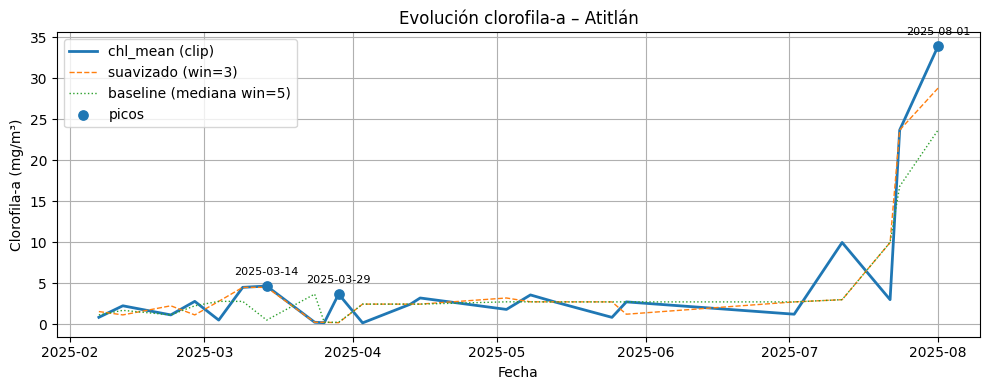

Picos detectados (3):
 • 2025-03-14  chl_mean≈4.64
 • 2025-03-29  chl_mean≈3.66
 • 2025-08-01  chl_mean≈33.93

=== Amatitlán ===
Arrays NumPy: cube=(30, 924, 1366), X=(30, 124771), pix_agua=124771


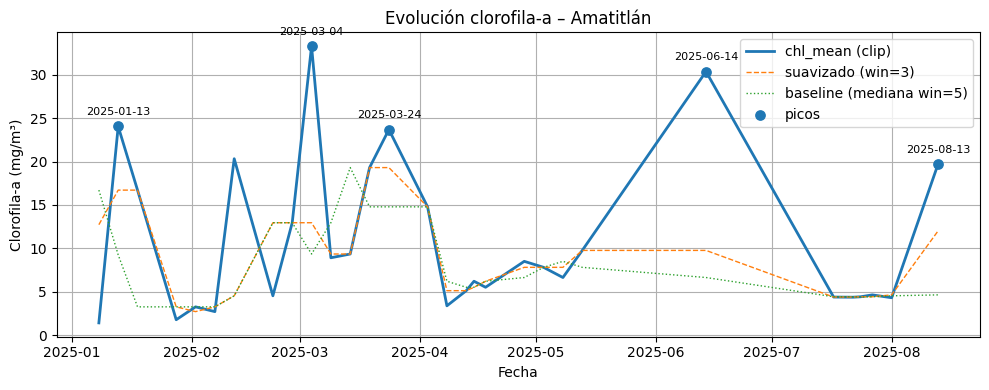

Picos detectados (5):
 • 2025-01-13  chl_mean≈24.05
 • 2025-03-04  chl_mean≈33.30
 • 2025-03-24  chl_mean≈23.69
 • 2025-06-14  chl_mean≈30.38
 • 2025-08-13  chl_mean≈19.70


In [9]:
# === PASOS 5 y 6: desde *_chl.tif a NumPy + análisis temporal (sin guardar archivos) ===
import os, glob, re
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

CYANO_OUT = "ciano_outputs"
LAKES = {
    "Atitlán":   os.path.join(CYANO_OUT, "descargas_atitlan_fechas"),
    "Amatitlán": os.path.join(CYANO_OUT, "descargas_amatitlan"),
}
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")

# --- utilidades ---
def find_chl_tifs(lake_root):
    paths = sorted(glob.glob(os.path.join(lake_root, "**", "*_chl.tif"), recursive=True))
    items = []
    for p in paths:
        m = DATE_RE.search(p)
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    items = sorted(items, key=lambda t: t[0])
    dates = [d.isoformat() for d,_ in items]
    paths = [p for _,p in items]
    if not paths:
        raise ValueError(f"No se encontraron *_chl.tif en {lake_root}")
    return dates, paths

def load_cube(paths):
    # asegura mismo tamaño para apilar
    with rasterio.open(paths[0]) as src0:
        H, W = src0.height, src0.width
        prof0 = (src0.transform, src0.crs)
    cube = np.full((len(paths), H, W), np.nan, dtype=np.float32)
    for i, p in enumerate(paths):
        with rasterio.open(p) as src:
            if (src.height, src.width) != (H, W):
                raise ValueError(f"Shape distinto en {p}: {(src.height,src.width)} vs {(H,W)}")
            cube[i] = src.read(1).astype(np.float32)   # ya trae NaN en tierra/nubes
    return cube, prof0

def water_mask_from_cube(cube):
    # True donde hay al menos un valor válido en el tiempo
    return np.isfinite(cube).any(axis=0)

def cube_to_matrix(cube, water_mask):
    H, W = water_mask.shape
    valid_idx = np.where(water_mask.ravel())[0]
    T = cube.shape[0]
    X = np.full((T, valid_idx.size), np.nan, dtype=np.float32)
    for t in range(T):
        X[t] = cube[t].ravel()[valid_idx]
    return X, valid_idx, (H, W)

def numeric_time(dates_iso):
    idx = pd.to_datetime(dates_iso)
    timestamp_s  = (idx.view("int64") // 10**9).astype("int64")
    date_ordinal = np.array([d.toordinal() for d in idx.to_pydatetime()], dtype="int64")
    doy          = idx.dayofyear.values.astype("int64")
    return idx, timestamp_s, date_ordinal, doy

def per_date_stats(cube):
    T = cube.shape[0]
    flat = cube.reshape(T, -1)
    return (
        np.nanmean(flat, axis=1),
        np.nanmedian(flat, axis=1),
        np.nanpercentile(flat, 90, axis=1),
        np.nanstd(flat, axis=1),
        np.sum(np.isfinite(flat), axis=1).astype(int),
    )

# --- detector de picos robusto (baseline = mediana móvil, umbral = k*MAD) ---
def robust_peaks(dates, y_clip, win=5, k_mad=2.0, min_height=10.0, distance=2):
    """
    Marca picos cuando:
      - y - mediana_móvil(win) > k_mad * MAD(residuo)  (robusto a outliers)
      - o y >= min_height (umbral absoluto)
    Además, aplica 'distance' para no marcar días adyacentes como picos distintos.
    """
    s = pd.Series(y_clip, index=dates)
    base = s.rolling(win, center=True, min_periods=1).median()
    resid = s - base
    mad = np.median(np.abs(resid.values - np.median(resid.values)))
    thr = max(k_mad * mad, 1e-6)

    cand = ((resid.values > thr) | (s.values >= min_height))
    idx = np.where(cand)[0]
    if idx.size == 0:
        return np.array([], dtype=int), base.values, resid.values, thr

    # agrupar candidatos cercanos y quedarnos con el máximo local de cada grupo
    keep = []
    start = 0
    while start < len(idx):
        group = [idx[start]]
        j = start + 1
        while j < len(idx) and (idx[j] - group[-1]) <= distance:
            group.append(idx[j])
            j += 1
        k = group[np.argmax(s.values[group])]
        keep.append(k)
        start = j

    return np.array(keep, dtype=int), base.values, resid.values, thr

# --- ejecutar para ambos lagos ---
results = {}
for lake, root in LAKES.items():
    print(f"\n=== {lake} ===")
    # 5) cargar a NumPy
    dates, paths = find_chl_tifs(root)
    cube, _ = load_cube(paths)                          # cube: T×H×W (float32)
    water_mask = water_mask_from_cube(cube)             # H×W (bool)
    X, valid_idx, hw = cube_to_matrix(cube, water_mask) # X: T×Npix válidos

    print(f"Arrays NumPy: cube={cube.shape}, X={X.shape}, pix_agua={water_mask.sum()}")

    # 6.1) índice promedio por fecha
    mean, median, p90, std, water_px = per_date_stats(cube)
    idx_dt, ts_s, ord_d, doy = numeric_time(dates)
    df = pd.DataFrame({
        "chl_mean": mean, "median": median, "p90": p90, "std": std, "water_px": water_px,
        "timestamp_s": ts_s, "date_ordinal": ord_d, "doy": doy
    }, index=idx_dt).sort_index()
    df.index.name = "date"

    # 6.2) gráfica de evolución temporal (suavizado visual ventana 3)
    y  = np.clip(df["chl_mean"].values, 0, 500)
    ys = pd.Series(y, index=df.index).rolling(3, center=True, min_periods=1).median().values

    # 6.3) picos con baseline robusto (mediana móvil win=5)
    pk, base_vals, resid_vals, thr = robust_peaks(df.index, y, win=5, k_mad=2.0, min_height=10.0, distance=2)

    # Plot final con baseline y picos
    plt.figure(figsize=(10,4))
    plt.plot(df.index, y, label="chl_mean (clip)", linewidth=2)
    plt.plot(df.index, ys, "--", label="suavizado (win=3)", linewidth=1)
    plt.plot(df.index, base_vals, ":", label="baseline (mediana win=5)", linewidth=1)
    if pk.size:
        plt.scatter(df.index[pk], y[pk], s=45, zorder=3, label="picos")
        for i in pk:
            plt.annotate(df.index[i].strftime("%Y-%m-%d"),
                         (df.index[i], y[i]), textcoords="offset points",
                         xytext=(0,8), ha="center", fontsize=8)
    plt.title(f"Evolución clorofila-a – {lake}")
    plt.xlabel("Fecha"); plt.ylabel("Clorofila-a (mg/m³)")
    plt.grid(True); plt.legend(); plt.tight_layout()
    plt.show()

    # Reporte de picos
    if pk.size:
        print(f"Picos detectados ({len(pk)}):")
        for i in pk:
            print(f" • {df.index[i].date()}  chl_mean≈{float(y[i]):.2f}")
    else:
        print("Sin picos con estos parámetros (ajusta k_mad/min_height/ventana).")

    # (opcional) exportar en disco:
    # df.assign(chl_mean_clip=y, chl_mean_smooth=ys, baseline=base_vals).to_csv(f"{lake.lower()}_timeseries_clean.csv")
    # pd.DataFrame({"date": df.index[pk], "chl_mean_clip": y[pk]}).to_csv(f"{lake.lower()}_peaks.csv", index=False)

    results[lake] = {"cube": cube, "X": X, "water_mask": water_mask, "df": df,
                     "peaks_idx": pk, "dates": np.array(dates)}

7

In [14]:
# === PASO 7 (solo guardar HTML): mapas por fechas pico y visor comparativo por lago ===
import os, glob, re
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import folium
from branca.colormap import LinearColormap

CYANO_OUT = "ciano_outputs"
LAKES_DIR = {
    "Atitlán":   os.path.join(CYANO_OUT, "descargas_atitlan_fechas"),
    "Amatitlán": os.path.join(CYANO_OUT, "descargas_amatitlan"),
}
# Fechas pico (tu lista)
PEAK_DATES = {
    "Atitlán":   ["2025-01-11","2025-01-26","2025-03-02","2025-03-14","2025-04-16","2025-07-17","2025-08-01"],
    "Amatitlán": ["2025-01-13","2025-03-04","2025-03-24","2025-06-14","2025-08-13"],
}
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")
os.makedirs("html_maps", exist_ok=True)

def list_chl_tifs(lake_root):
    paths = sorted(glob.glob(os.path.join(lake_root, "**", "*_chl.tif"), recursive=True))
    items = []
    for p in paths:
        m = DATE_RE.search(p)
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    items = sorted(items, key=lambda t: t[0])
    return [d.isoformat() for d,_ in items], [p for _,p in items]

def path_for_date(dates, paths, target):
    """Devuelve el tif exacto para 'target' (YYYY-MM-DD).
       Si no existe exacto, usa el más cercano temporalmente."""
    if target in dates:
        return paths[dates.index(target)], target, True
    # más cercano
    dt = pd.to_datetime(dates)
    t  = pd.to_datetime(target)
    i  = int(np.argmin(np.abs((dt - t).days)))
    return paths[i], dates[i], False

def to_epsg4326(path, dst_transform=None, dst_width=None, dst_height=None):
    with rasterio.open(path) as src:
        src_crs, src_tr = src.crs, src.transform
        a = src.read(1).astype(np.float32)
        if src.nodata is not None:
            a[a == src.nodata] = np.nan
        if (src_crs is None) or (src_crs.to_string() == "EPSG:4326"):
            arr = a
            tr_out = src_tr
            if dst_transform is not None:
                arr2 = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
                reproject(a, arr2, src_transform=src_tr, src_crs=src_crs,
                          dst_transform=dst_transform, dst_crs="EPSG:4326",
                          resampling=Resampling.bilinear,
                          src_nodata=np.nan, dst_nodata=np.nan)
                arr = arr2; tr_out = dst_transform
        else:
            if dst_transform is None:
                dst_transform, dst_width, dst_height = calculate_default_transform(
                    src_crs, "EPSG:4326", src.width, src.height, *src.bounds
                )
            arr = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
            reproject(a, arr, src_transform=src_tr, src_crs=src_crs,
                      dst_transform=dst_transform, dst_crs="EPSG:4326",
                      resampling=Resampling.bilinear,
                      src_nodata=np.nan, dst_nodata=np.nan)
            tr_out = dst_transform
        H, W = arr.shape
        left, bottom, right, top = array_bounds(H, W, tr_out)
        return arr, tr_out, (bottom, left, top, right)  # (S,W,N,E)

def common_vmin_vmax(arr_list, p_low=5, p_high=95, clamp=(0, 100)):
    vals = np.concatenate([a[np.isfinite(a)] for a in arr_list if np.isfinite(a).any()])
    if vals.size == 0:
        return 0.0, 10.0
    vmin = max(clamp[0], np.percentile(vals, p_low))
    vmax = min(clamp[1], np.percentile(vals, p_high))
    if vmin >= vmax: vmax = vmin + 1.0
    return float(vmin), float(vmax)

def rgba_for_folium(a, vmin, vmax, cmap="viridis"):
    import matplotlib.cm as cm, matplotlib.colors as colors
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mapper = cm.ScalarMappable(norm=norm, cmap=cmap)
    rgba = mapper.to_rgba(a, bytes=True)
    rgba[~np.isfinite(a)] = [0,0,0,0]
    return rgba

for lake, in_dir in LAKES_DIR.items():
    print(f"\n=== {lake} ===")
    dates_all, paths_all = list_chl_tifs(in_dir)

    # 1) Reproyecta todas las fechas solicitadas a una malla común
    selected = []
    base_arr, base_tr, base_bounds = None, None, None
    for t in PEAK_DATES[lake]:
        tif_path, used_date, exact = path_for_date(dates_all, paths_all, t)
        if base_arr is None:
            base_arr, base_tr, base_bounds = to_epsg4326(tif_path)
            H, W = base_arr.shape
            arr = base_arr
        else:
            arr, _, _ = to_epsg4326(tif_path, dst_transform=base_tr, dst_width=W, dst_height=H)
        selected.append((used_date, arr))
        if not exact:
            print(f"  ⚠️ {t} no exacta, usando la más cercana: {used_date}")

    # 2) Escala común por lago
    vmin, vmax = common_vmin_vmax([a for _, a in selected])

    # 3) Guardar un HTML por fecha (sin mostrar)
    south, west, north, east = base_bounds
    lat, lon = (south+north)/2, (west+east)/2
    for d, arr in selected:
        rgba = rgba_for_folium(arr, vmin=vmin, vmax=vmax)
        m = folium.Map(location=[lat, lon], zoom_start=11, tiles="CartoDB positron")
        folium.raster_layers.ImageOverlay(
            image=rgba, bounds=[[south, west], [north, east]],
            opacity=0.75, name=f"{lake} – {d}", interactive=True
        ).add_to(m)
        LinearColormap(['#440154','#31688e','#35b779','#fde725'],
                       vmin=vmin, vmax=vmax, caption="Clorofila-a (mg/m³)").add_to(m)
        folium.LayerControl().add_to(m)
        html_name = os.path.join("html_maps", f"mapa_{lake}_{d}.html".replace(" ", "_"))
        m.save(html_name)
        print(f"  ✔ Guardado: {html_name}")

    # 4) Visor comparativo (todas las fechas del lago en capas) — también solo HTML
    mcomp = folium.Map(location=[lat, lon], zoom_start=11, tiles="CartoDB positron")
    for d, arr in selected:
        rgba = rgba_for_folium(arr, vmin=vmin, vmax=vmax)
        folium.raster_layers.ImageOverlay(
            image=rgba, bounds=[[south, west], [north, east]],
            opacity=0.75, name=d, interactive=True
        ).add_to(mcomp)
    LinearColormap(['#440154','#31688e','#35b779','#fde725'],
                   vmin=vmin, vmax=vmax, caption="Clorofila-a (mg/m³)").add_to(mcomp)
    folium.LayerControl().add_to(mcomp)
    comp_name = os.path.join("html_maps", f"mapa_comparativo_{lake}.html".replace(" ", "_"))
    mcomp.save(comp_name)
    print(f"  ✔ Visor comparativo guardado: {comp_name}")


=== Atitlán ===
  ⚠️ 2025-01-11 no exacta, usando la más cercana: 2025-02-07
  ⚠️ 2025-01-26 no exacta, usando la más cercana: 2025-02-07
  ⚠️ 2025-03-02 no exacta, usando la más cercana: 2025-03-04
  ⚠️ 2025-04-16 no exacta, usando la más cercana: 2025-04-15
  ⚠️ 2025-07-17 no exacta, usando la más cercana: 2025-07-12
  ✔ Guardado: html_maps\mapa_Atitlán_2025-02-07.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-02-07.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-03-04.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-03-14.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-04-15.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-07-12.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-08-01.html
  ✔ Visor comparativo guardado: html_maps\mapa_comparativo_Atitlán.html

=== Amatitlán ===
  ✔ Guardado: html_maps\mapa_Amatitlán_2025-01-13.html
  ✔ Guardado: html_maps\mapa_Amatitlán_2025-03-04.html
  ✔ Guardado: html_maps\mapa_Amatitlán_2025-03-24.html
  ✔ Guardado: html_maps\mapa_Amatitlán_2025-06-14.h

[SCL] 2025-02-07 -> multi :: openEO_2025-02-07Z.tif (band=10)


C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\725539549.py:198: RuntimeWarning: invalid value encountered in cast
  scl_i = scl.astype(np.int16)


[SCL] 2025-02-12 -> multi :: openEO_2025-02-12Z.tif (band=10)


C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\725539549.py:198: RuntimeWarning: invalid value encountered in cast
  scl_i = scl.astype(np.int16)


[SCL] 2025-02-22 -> multi :: openEO_2025-02-22Z.tif (band=10)


...

C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\725539549.py:198: RuntimeWarning: invalid value encountered in cast
  scl_i = scl.astype(np.int16)


[SCL] 2025-08-01 -> multi :: openEO_2025-08-01Z.tif (band=10)


C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\725539549.py:198: RuntimeWarning: invalid value encountered in cast
  scl_i = scl.astype(np.int16)


✅ Resumen guardado: diagnosticos_v2\resumen_Atitlán_v2.csv
⚠️ Fechas con cobertura < 5.0% (considera descartarlas):
  • 2025-02-07: coverage=0.01%  valid=79/1182818  SCL=True QA60=False
  • 2025-02-12: coverage=0.33%  valid=3243/993317  SCL=True QA60=False
  • 2025-02-22: coverage=0.01%  valid=93/1034001  SCL=True QA60=False
  • 2025-02-27: coverage=0.01%  valid=112/1148542  SCL=True QA60=False
  • 2025-03-04: coverage=0.00%  valid=7/1214829  SCL=True QA60=False
  • 2025-03-09: coverage=0.00%  valid=29/1218158  SCL=True QA60=False
  • 2025-03-14: coverage=0.00%  valid=2/1224700  SCL=True QA60=False
  • 2025-03-24: coverage=0.00%  valid=5/1209047  SCL=True QA60=False
  • 2025-03-26: coverage=0.00%  valid=1/1224784  SCL=True QA60=False
  • 2025-03-29: coverage=4.49%  valid=53061/1180907  SCL=True QA60=False
  • 2025-04-03: coverage=0.00%  valid=2/1167201  SCL=True QA60=False
  • 2025-04-13: coverage=0.00%  valid=1/1225425  SCL=True QA60=False
  • 2025-04-15: coverage=0.00%  valid=1/12261

C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\725539549.py:342: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0,0,1,0.97)); plt.show()


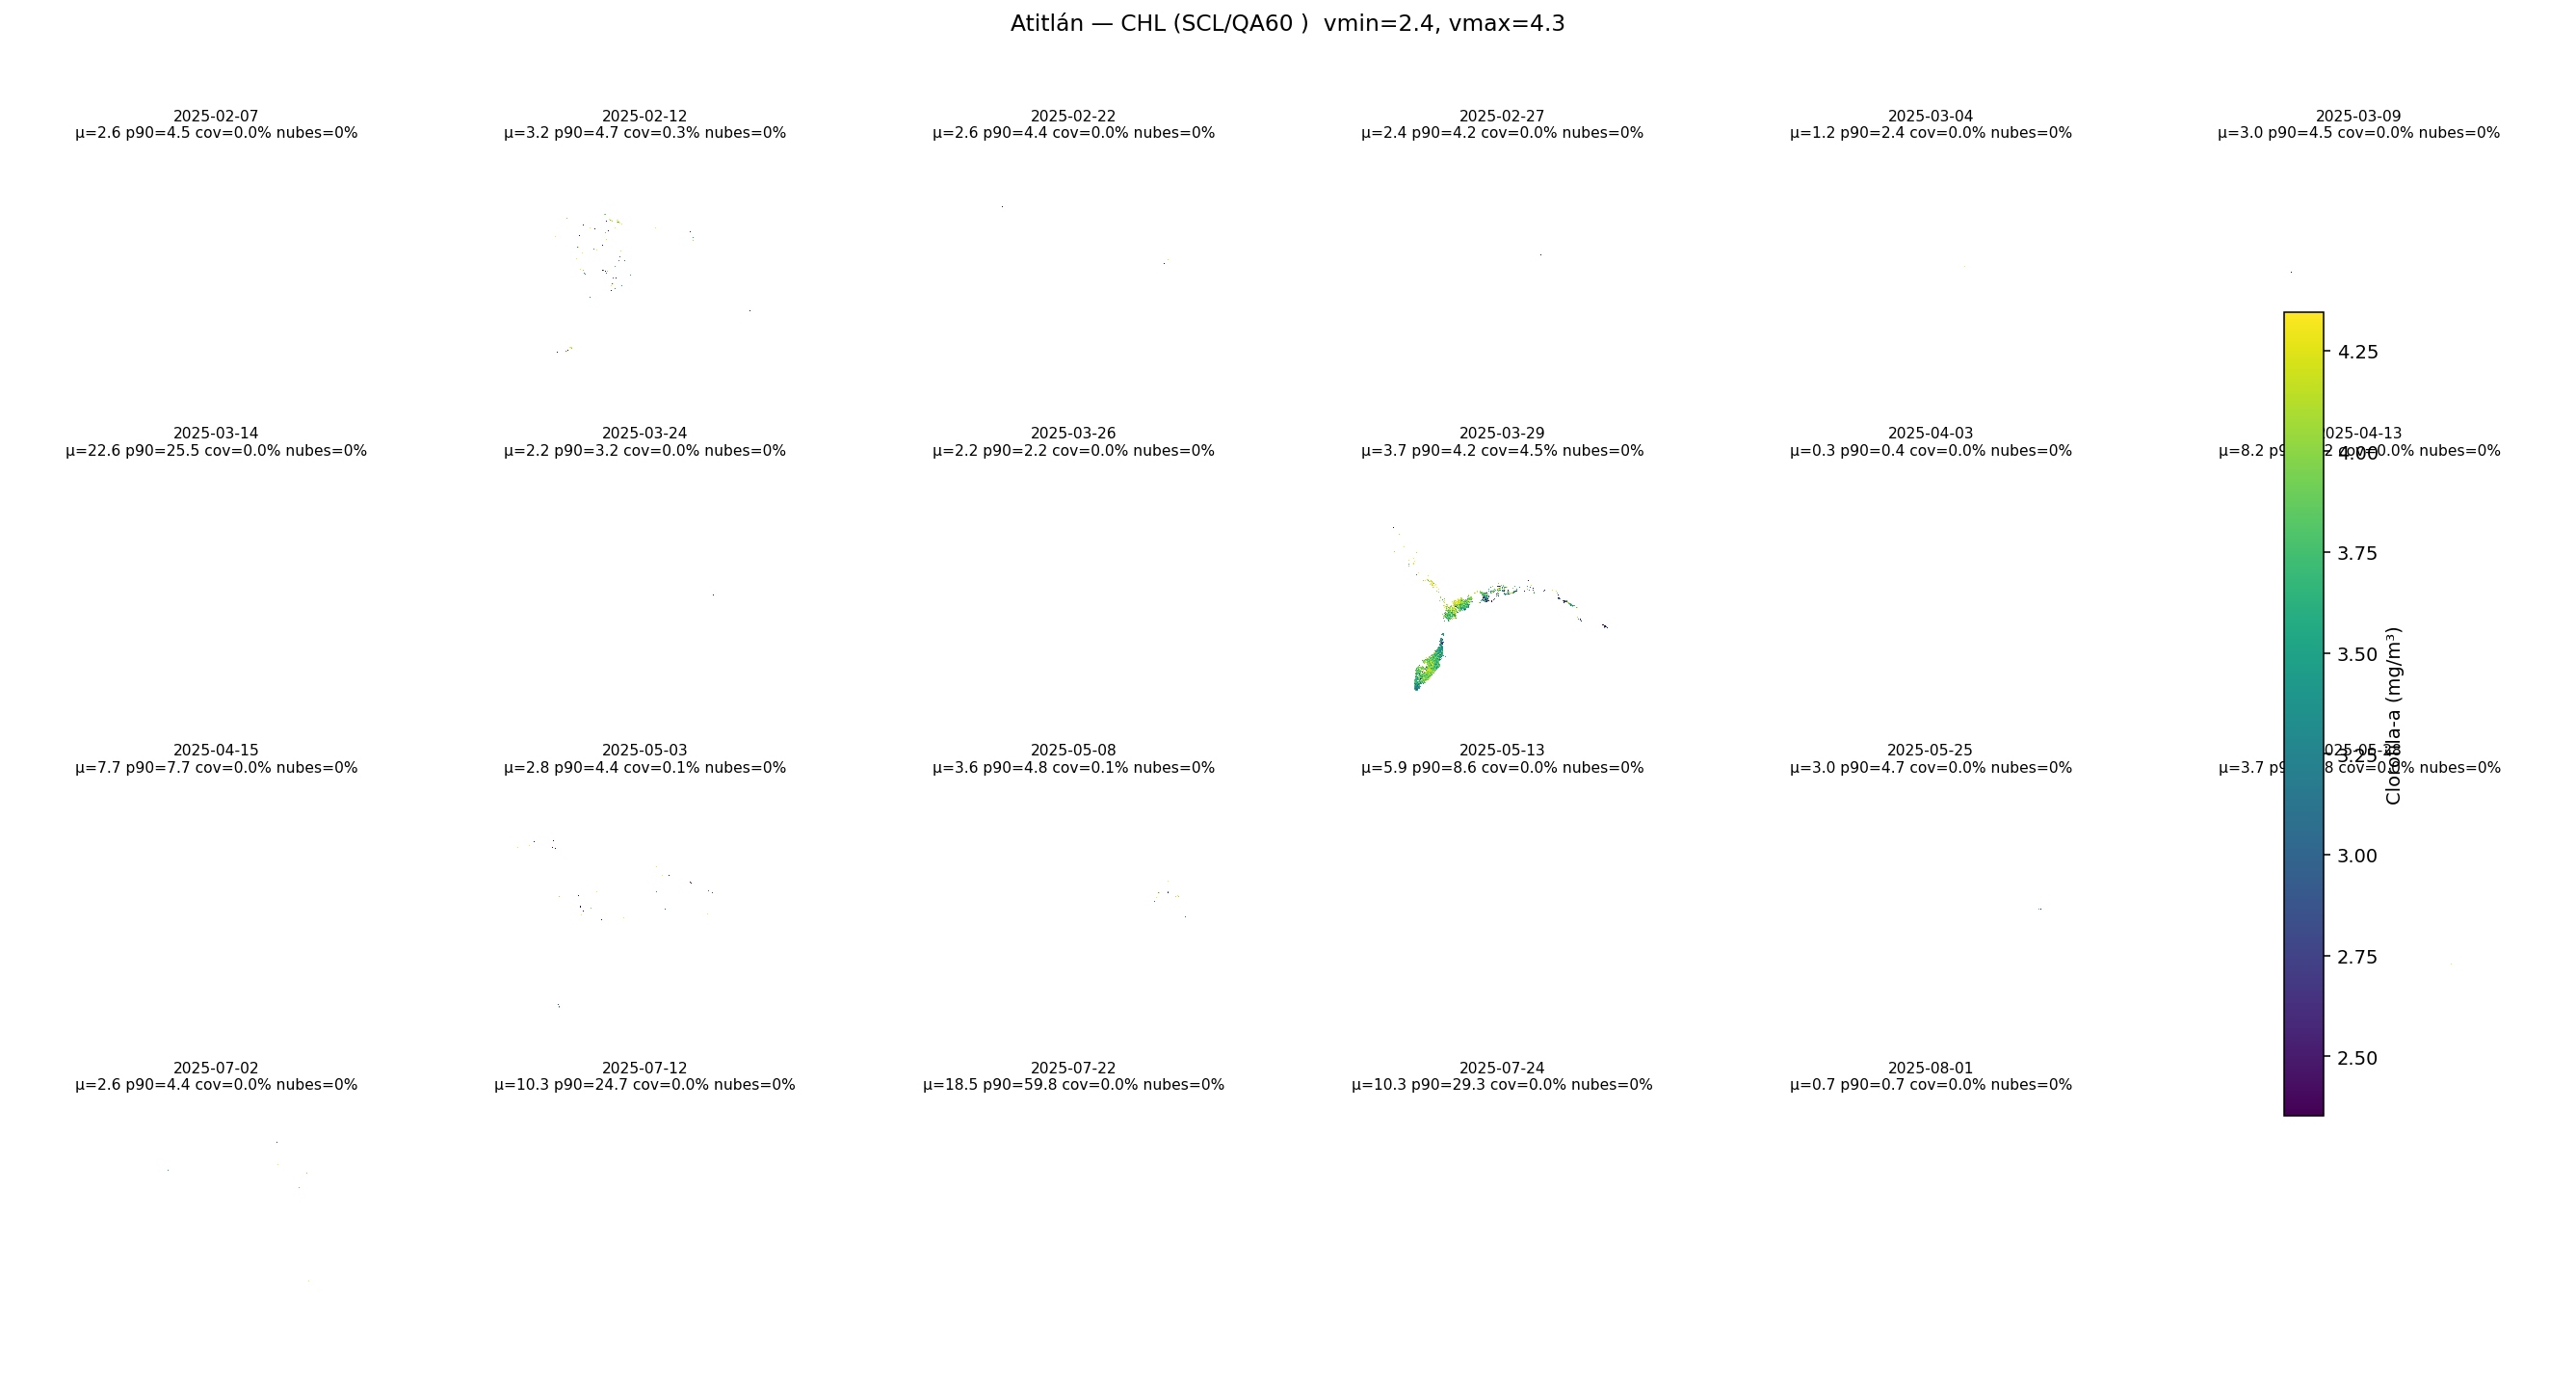

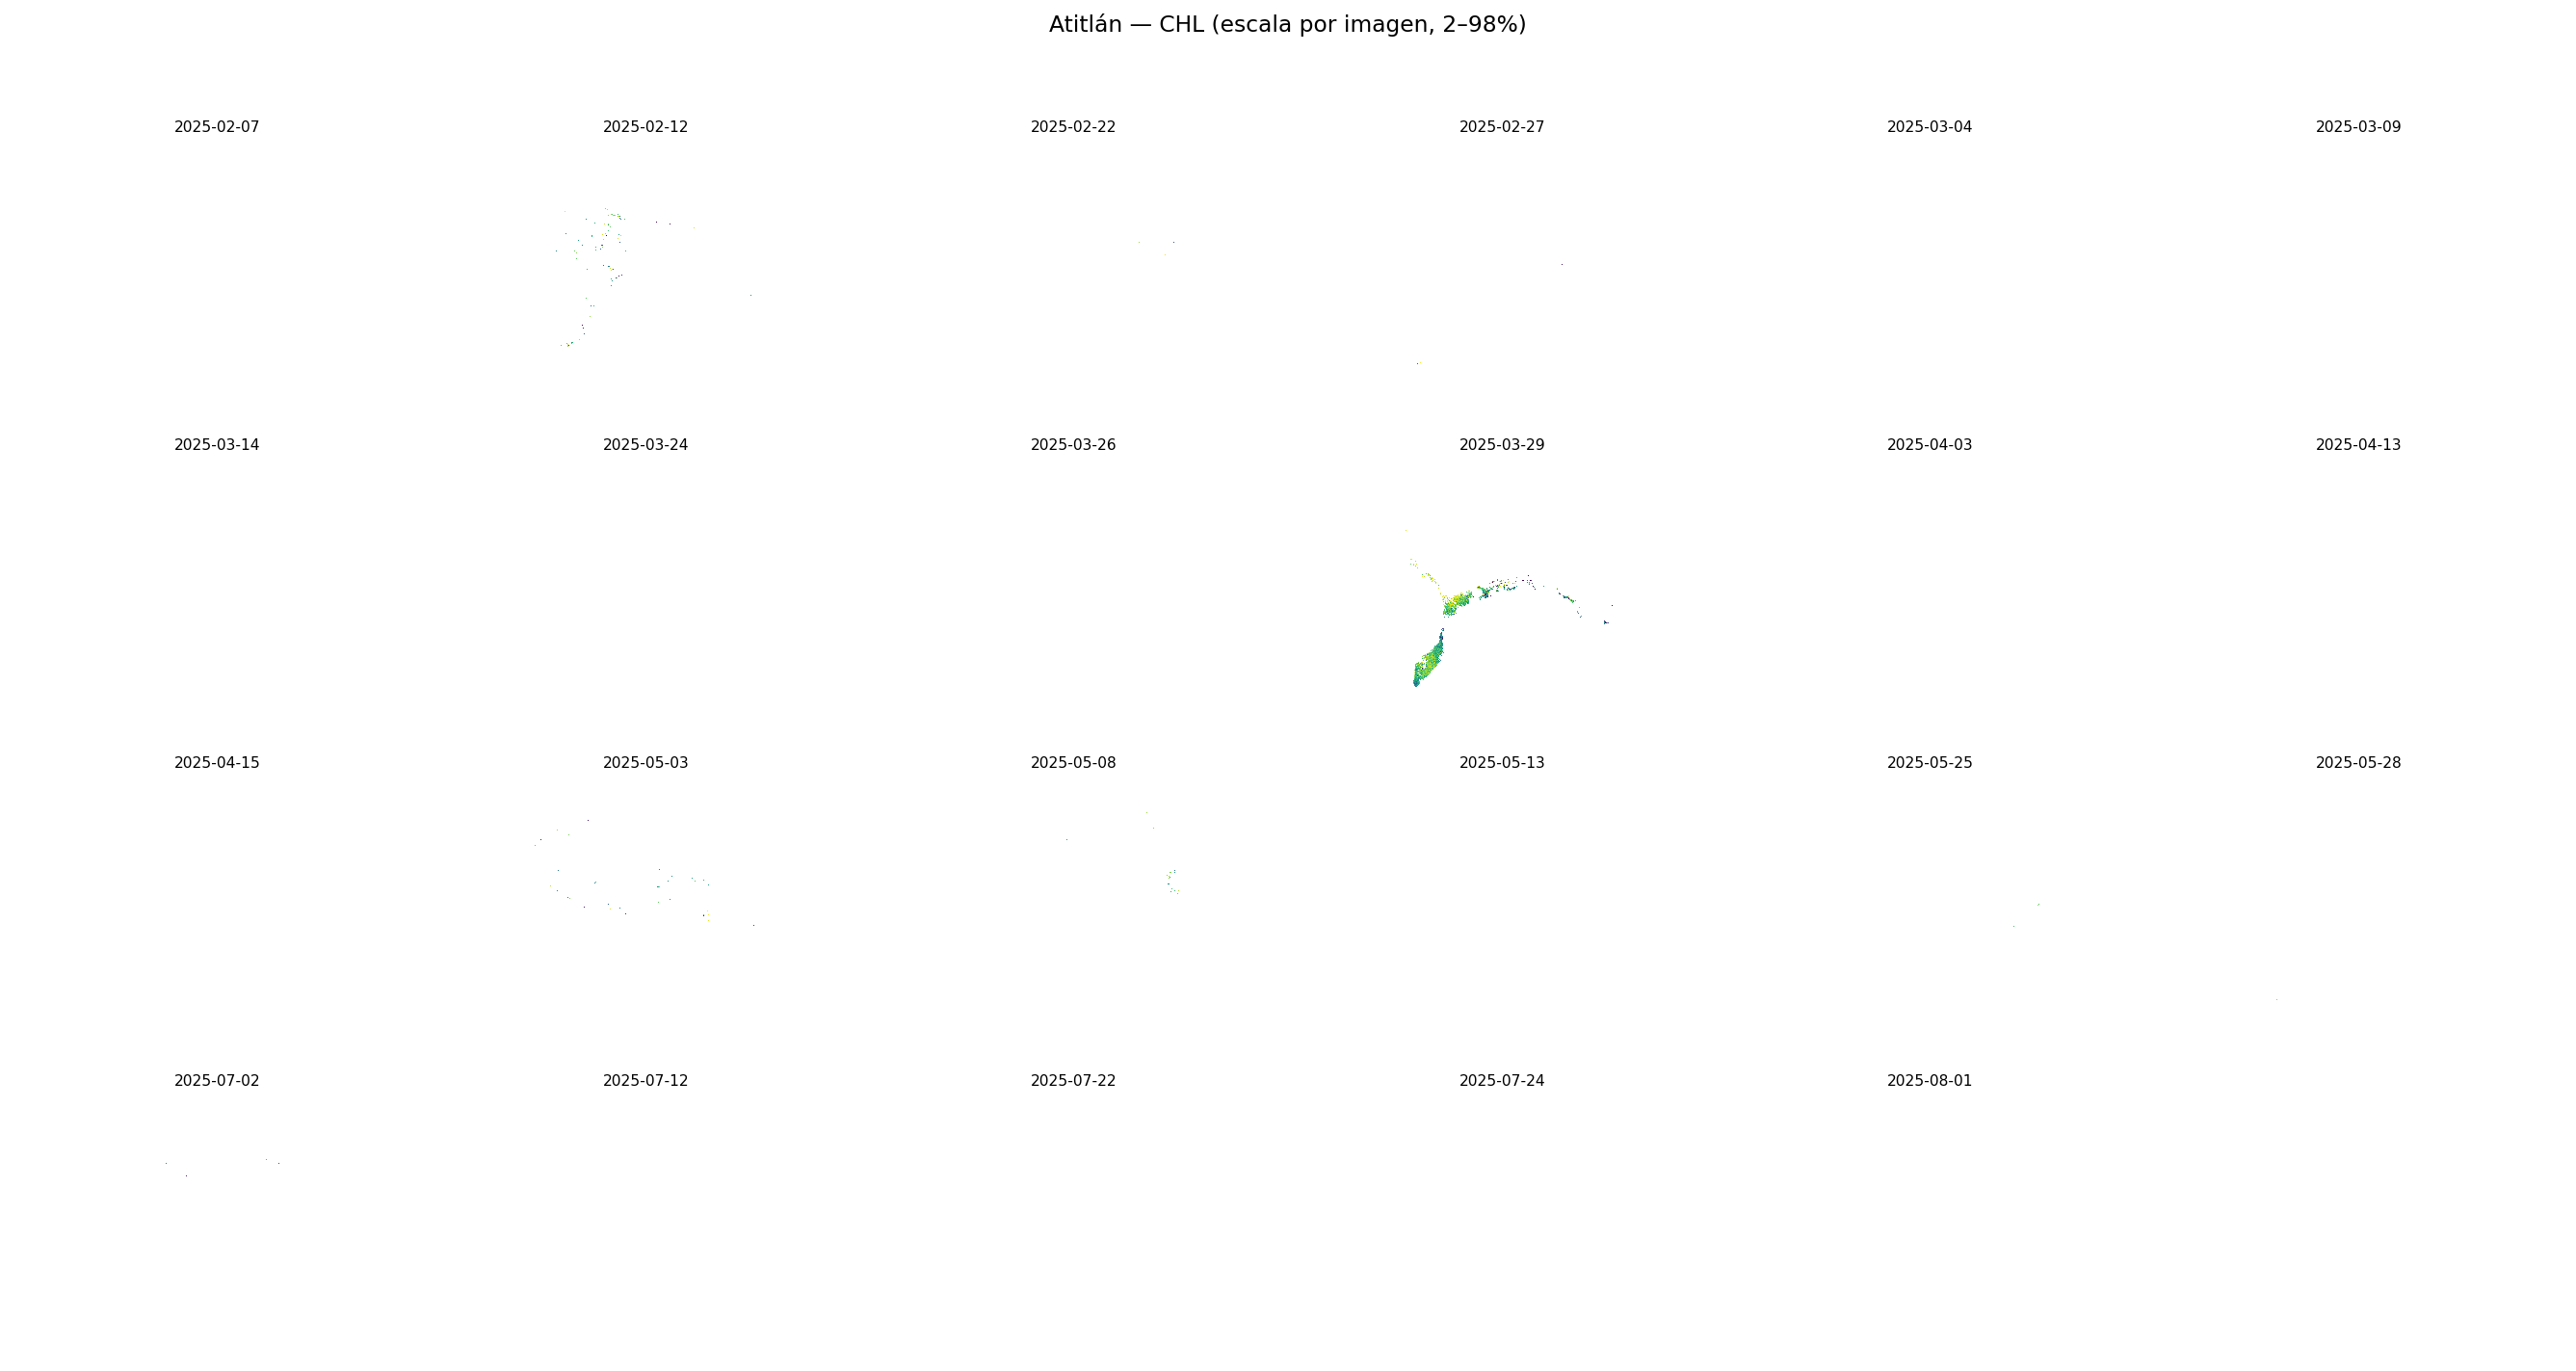

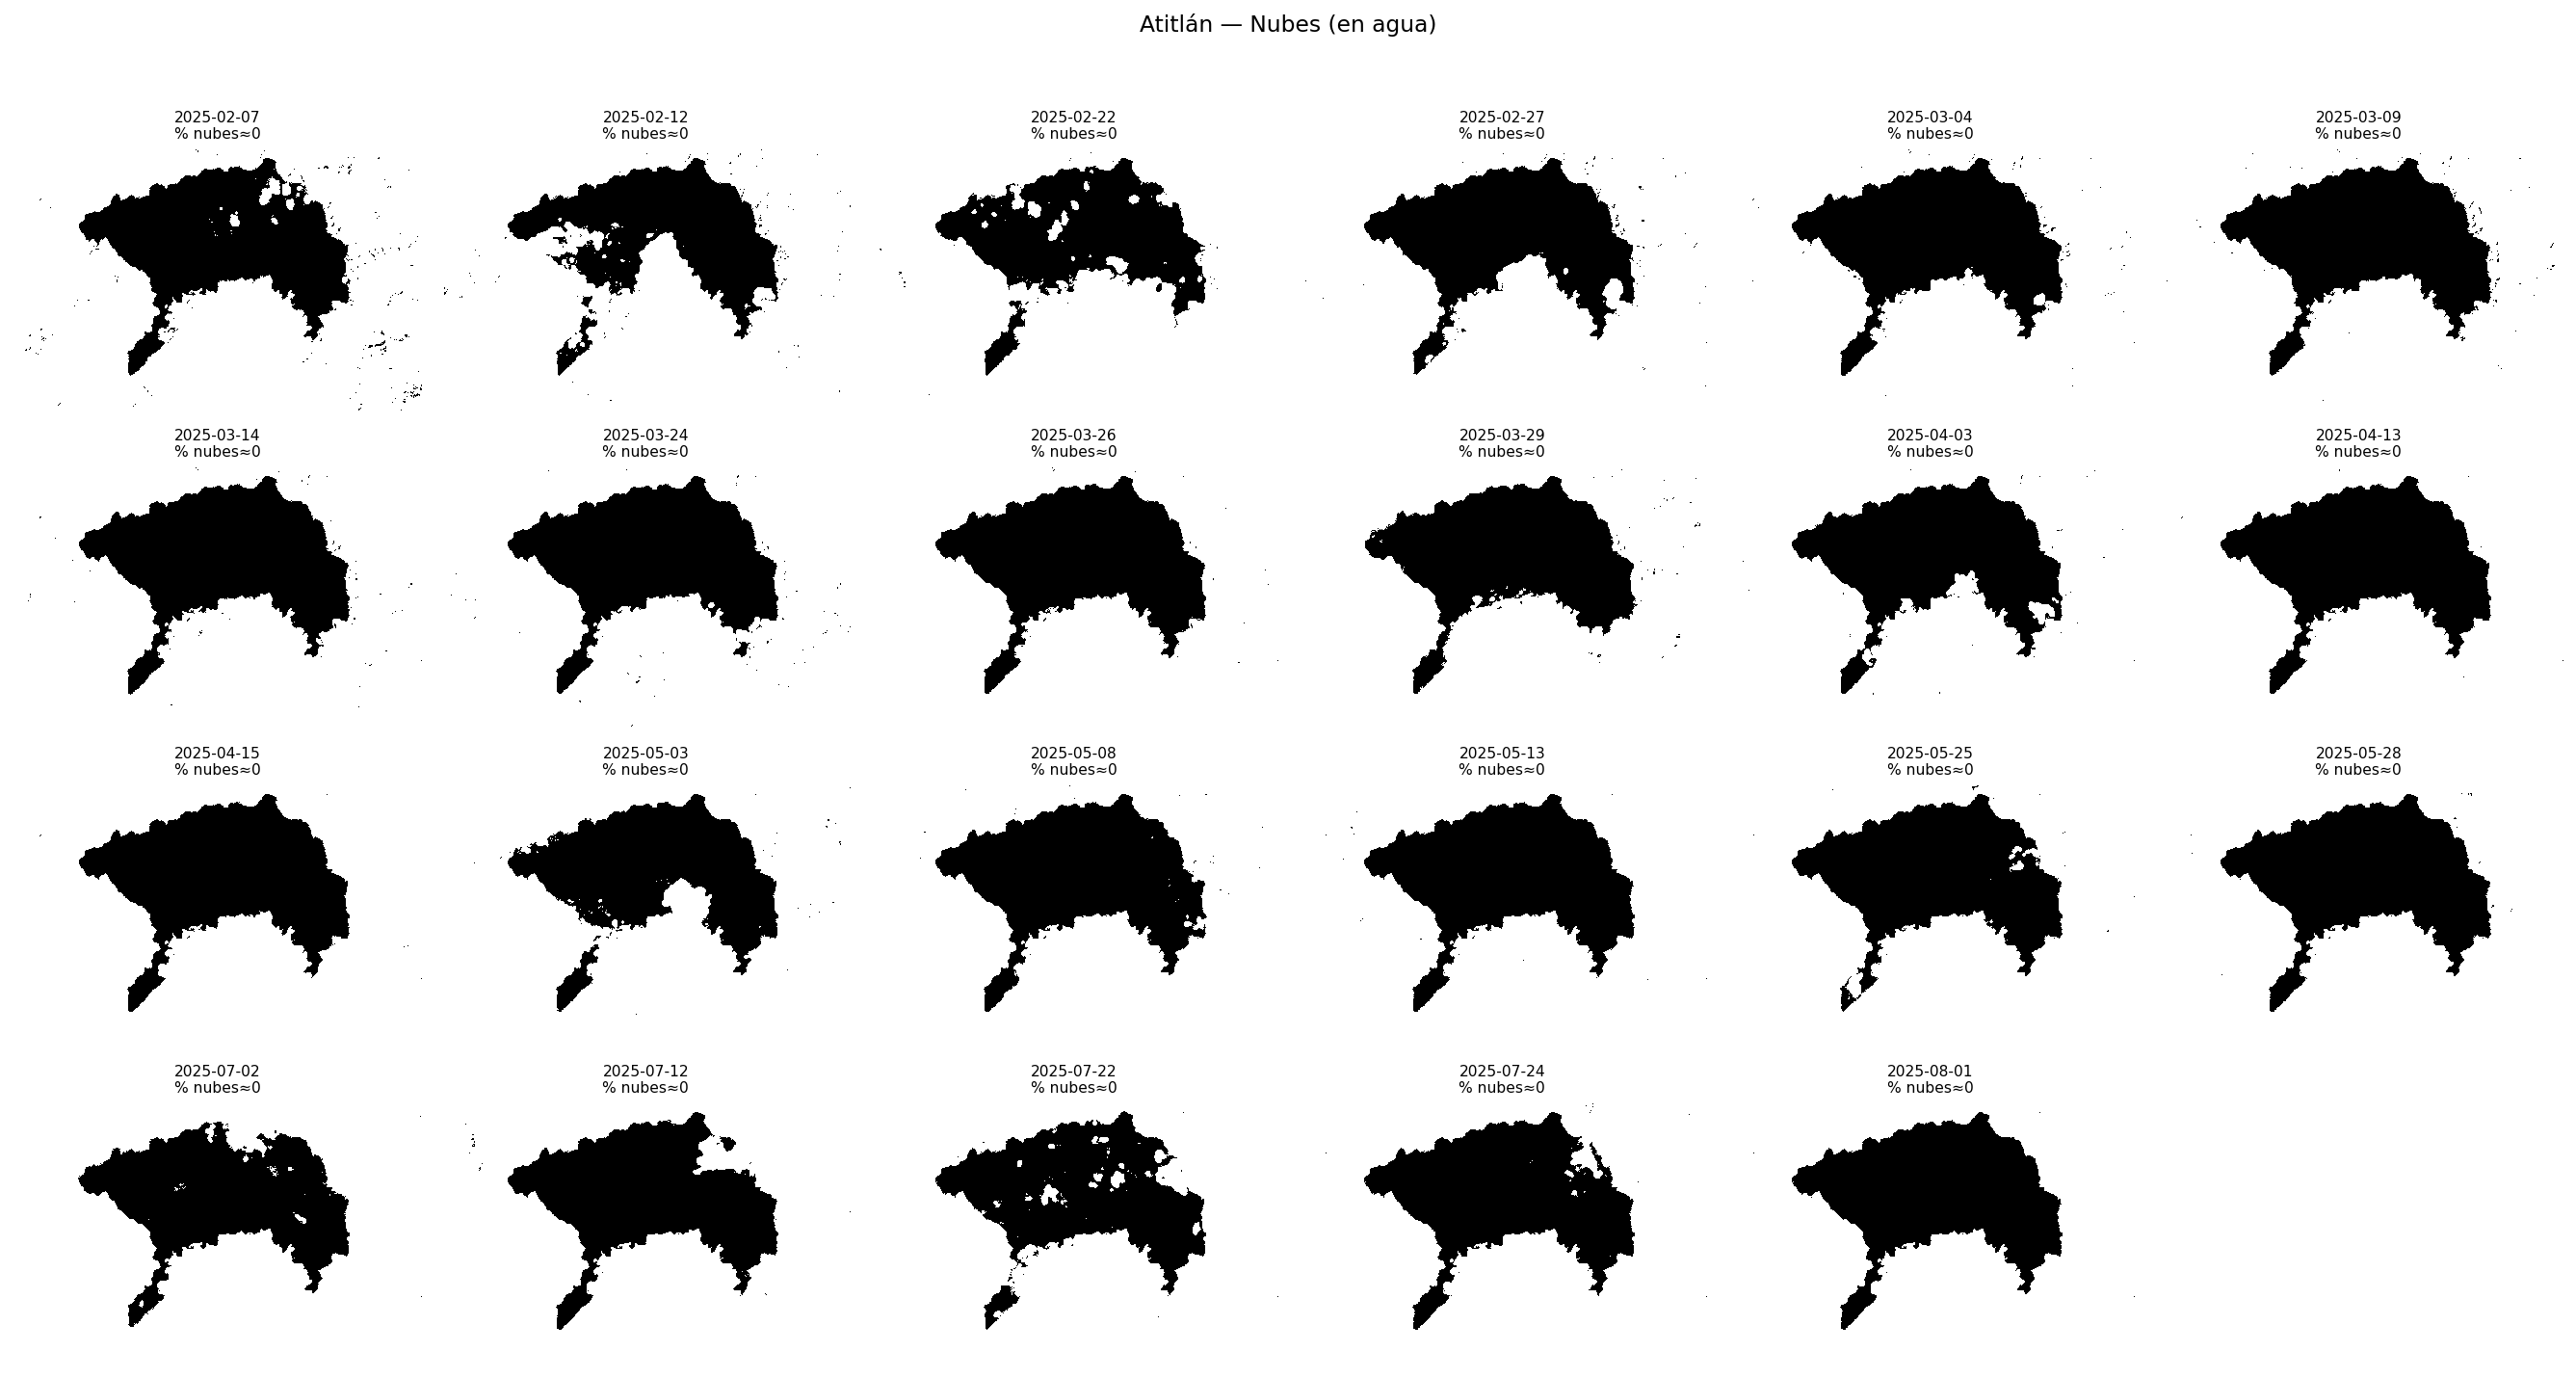

ℹ️ No se encontraron multibandas con B04/B03/B02 para mostrar RGB (opcional).


In [20]:
# ===============================================================
# Explorer V2.1 — CHL + nubosidad + métricas (robusto, Jupyter)
# Requisitos: rasterio, numpy, pandas, matplotlib  (opcional: scipy)
# pip install rasterio numpy pandas matplotlib scipy
# ===============================================================

import os, glob, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import (
    calculate_default_transform, reproject, Resampling, transform_geom
)
from rasterio.transform import array_bounds
from rasterio import features
import matplotlib.pyplot as plt

# ------------------ CONFIG ------------------
LAKE_NAME = "Atitlán"


# Carpeta que contiene tus *_chl.tif
CHL_DIR = "ciano_outputs/descargas_atitlan_fechas"

# Carpetas donde buscar SCL/QA60 y multibandas (primero donde están los openEO_*Z.tif)
SEARCH_SCL_DIRS = [
    "descargas_atitlan_fechas",              # <- aquí están los openEO_YYYY-MM-DDZ.tif
    "ciano_outputs/descargas_atitlan_fechas" # <- por si en algún caso quedan juntos
]

# (opcional) polígono del lago si lo tienes
LAKE_POLYGON_GEOJSON = "lago_atitlan.geojson"
USE_LAKE_POLYGON = os.path.exists(LAKE_POLYGON_GEOJSON)

OUT_DIR   = "diagnosticos_v2"
NCOLS     = 6

# Escala global CHL para comparación entre fechas
P_LOW, P_HIGH = 5, 95
CLAMP = (0, 100)

# Mínimo % de superficie de lago con CHL válido para considerar la fecha
MIN_COVERAGE_PCT = 5.0

# Máscara estricta
USE_SCL_MASK        = True
USE_QA60_FALLBACK   = True
KEEP_ONLY_WATER     = True
ERODE_WATER_PIXELS  = 1                 # 0 = sin erosión; 1–2 recomendado
SCL_BAD_CLASSES     = {0,1,3,4,5,7,8,9,10,11}

# Debug (imprime qué archivo usa como SCL para algunas fechas)
DEBUG_PICK = True

# ------------------ UTILIDADES ------------------
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

def find_chl_tifs(root):
    paths = sorted(glob.glob(os.path.join(root, "**", "*_chl.tif"), recursive=True))
    items = []
    for p in paths:
        m = DATE_RE.search(os.path.basename(p))
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    items.sort(key=lambda t: t[0])
    return [(d.isoformat(), p) for d,p in items]

def _list_all_by_date(dirs, date_iso):
    cands = []
    for d in dirs:
        cands.extend(sorted(glob.glob(os.path.join(d, f"**/*{date_iso}*.tif"), recursive=True)))
    return cands

def _prefer_base_openEO(p):
    """
    score: 0 = 'openEO_YYYY-MM-DDZ.tif' exacto, 1 = otros; segundo criterio: nombre más corto.
    Evita elegir derivados (_chl.tif, _cyano_rgb.tif).
    """
    b = os.path.basename(p).lower()
    exact = re.search(r"^openeo_\d{4}-\d{2}-\d{2}z\.tif$", b, re.I) is not None
    return (0 if exact else 1, len(b))

def _pick_multiband_for_date(dirs, date_iso, purpose="SCL"):
    # Filtra candidatos por nombre (descarta derivados)
    wanted = []
    for p in _list_all_by_date(dirs, date_iso):
        bl = os.path.basename(p).lower()
        if bl.endswith("_chl.tif"):
            continue
        if "cyano_rgb" in bl and purpose == "SCL":
            continue
        wanted.append(p)
    # Ordena: preferir openEO_YYYY-MM-DDZ.tif
    wanted.sort(key=_prefer_base_openEO)
    # Abre hasta dar con uno que cumpla bandas necesarias
    for p in wanted:
        try:
            with rasterio.open(p) as src:
                if purpose == "SCL" and src.count >= 10:
                    return p, src.count                 # SCL = última banda (habitual)
                if purpose in {"B02","B03","B04"} and src.count >= 3:
                    band_map = {"B02":1, "B03":2, "B04":3}
                    return p, band_map[purpose]
        except Exception:
            pass
    return None, None

def find_companion_by_date_multi(dirs, date_iso, tag):
    # 1) Archivos dedicados (p.ej., *SCL*.tif, *QA60*.tif), evitando derivados
    direct = []
    for d in dirs:
        direct += sorted(glob.glob(os.path.join(d, f"**/*{date_iso}*{tag}*.tif"), recursive=True))
    direct = [p for p in direct if not p.lower().endswith("_chl.tif") and "cyano_rgb" not in os.path.basename(p).lower()]
    if direct:
        return ("single", direct[0], 1)

    # 2) Si no hay, usa multibanda openEO
    p, idx = _pick_multiband_for_date(dirs, date_iso, "SCL" if tag=="SCL" else tag)
    if p:
        return ("multi", p, idx)

    return (None, None, None)

def reproject_to_match(src_path, dst_crs, dst_transform, dst_width, dst_height,
                       band_index=1, resampling=Resampling.nearest, nodata_to_nan=True):
    with rasterio.open(src_path) as src:
        out = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, band_index),
            destination=out,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=dst_transform,
            dst_crs=dst_crs,
            resampling=resampling,
            src_nodata=src.nodata if nodata_to_nan else None,
            dst_nodata=np.nan if nodata_to_nan else None,
        )
    return out

def _erode_bool(mask, iters):
    if iters <= 0: return mask
    try:
        from scipy.ndimage import binary_erosion
        return binary_erosion(mask, iterations=iters, structure=np.ones((3,3), dtype=bool))
    except Exception:
        return mask

def rasterize_polygon_onto(transform, shape, dst_crs, geojson_path):
    with open(geojson_path, "r", encoding="utf-8") as f:
        gj = json.load(f)
    # extrae geometrías
    geoms = []
    if gj.get("type") == "FeatureCollection":
        geometries = [feat["geometry"] for feat in gj["features"]]
    elif gj.get("type") == "Feature":
        geometries = [gj["geometry"]]
    else:
        geometries = [gj]
    # reproyecta a CRS del raster
    geoms = [(transform_geom("EPSG:4326", dst_crs.to_string(), g), 1) for g in geometries]
    mask = features.rasterize(
        geoms, out_shape=shape, transform=transform, fill=0, all_touched=True, dtype="uint8"
    ).astype(bool)
    return mask

# ------------------ LECTURA + MÁSCARAS + MÉTRICAS ------------------
def read_chl_masked(chl_path):
    with rasterio.open(chl_path) as src:
        chl = src.read(1).astype(np.float32)
        if src.nodata is not None:
            chl[chl == src.nodata] = np.nan
        chl[chl <= 0] = np.nan
        dst_crs, dst_tr = src.crs, src.transform
        H, W = src.height, src.width

    date_iso = DATE_RE.search(os.path.basename(chl_path)).group(1)

    # Lago: polígono (recomendado) o más tarde SCL==6
    if USE_LAKE_POLYGON:
        lake_mask = rasterize_polygon_onto(dst_tr, (H,W), dst_crs, LAKE_POLYGON_GEOJSON)
        if ERODE_WATER_PIXELS > 0:
            lake_mask = _erode_bool(lake_mask, ERODE_WATER_PIXELS)
    else:
        lake_mask = np.ones((H,W), dtype=bool)

    scl_used = qa_used = False
    cloud_mask = np.zeros((H,W), dtype=bool)

    if USE_SCL_MASK:
        kind, scl_path, scl_idx = find_companion_by_date_multi(SEARCH_SCL_DIRS, date_iso, "SCL")
        if scl_path:
            if DEBUG_PICK:
                print(f"[SCL] {date_iso} -> {kind} :: {os.path.basename(scl_path)} (band={scl_idx})")
            scl = reproject_to_match(scl_path, dst_crs, dst_tr, W, H, band_index=scl_idx, resampling=Resampling.nearest)
            scl_i = scl.astype(np.int16)
            scl_used = True
            bad = np.isin(scl_i, list(SCL_BAD_CLASSES))
            cloud_mask = bad.copy()
            if not USE_LAKE_POLYGON:  # si no hay polígono, usa agua SCL
                lake_mask = (scl_i == 6)
                if ERODE_WATER_PIXELS > 0:
                    lake_mask = _erode_bool(lake_mask, ERODE_WATER_PIXELS)

    if (not scl_used) and USE_QA60_FALLBACK:
        kind, qa_path, _ = find_companion_by_date_multi(SEARCH_SCL_DIRS, date_iso, "QA60")
        if qa_path:
            if DEBUG_PICK:
                print(f"[QA60] {date_iso} -> {kind} :: {os.path.basename(qa_path)}")
            qa = reproject_to_match(qa_path, dst_crs, dst_tr, W, H, band_index=1, resampling=Resampling.nearest)
            qa = qa.astype(np.uint16)
            qa_used = True
            cloud_mask = ((qa >> 10) & 1).astype(bool) | ((qa >> 11) & 1).astype(bool)

    # aplica máscaras
    valid = lake_mask & (~cloud_mask) & np.isfinite(chl)
    chl_masked = np.where(valid, chl, np.nan)

    # métricas
    lake_px = int(lake_mask.sum())
    clouds_pct = float((cloud_mask & lake_mask).sum())/max(lake_px,1)*100.0
    vals = chl_masked[np.isfinite(chl_masked)]
    if vals.size:
        stats = dict(
            chl_mean=float(np.nanmean(vals)),
            chl_median=float(np.nanmedian(vals)),
            chl_p90=float(np.nanpercentile(vals,90)),
            chl_p99=float(np.nanpercentile(vals,99)),
            chl_max=float(np.nanmax(vals)),
            valid_px=int(vals.size)
        )
    else:
        stats = dict(chl_mean=np.nan, chl_median=np.nan, chl_p90=np.nan,
                     chl_p99=np.nan, chl_max=np.nan, valid_px=0)

    return dict(date=date_iso, chl=chl_masked, lake_mask=lake_mask, cloud_mask=cloud_mask,
                scl_used=scl_used, qa_used=qa_used, stats=stats)

def make_rgb_quicklook(date_iso, dst_arr_shape, dst_tr, dst_crs):
    H, W = dst_arr_shape
    # intenta multibanda openEO del mismo día (B04/B03/B02)
    try:
        p4, idx4 = _pick_multiband_for_date(SEARCH_SCL_DIRS, date_iso, "B04")
        p3, idx3 = _pick_multiband_for_date(SEARCH_SCL_DIRS, date_iso, "B03")
        p2, idx2 = _pick_multiband_for_date(SEARCH_SCL_DIRS, date_iso, "B02")
        if not (p4 and p3 and p2):
            return None
        b04 = reproject_to_match(p4, dst_crs, dst_tr, W, H, band_index=idx4, resampling=Resampling.bilinear)
        b03 = reproject_to_match(p3, dst_crs, dst_tr, W, H, band_index=idx3, resampling=Resampling.bilinear)
        b02 = reproject_to_match(p2, dst_crs, dst_tr, W, H, band_index=idx2, resampling=Resampling.bilinear)
        stack = np.stack([b04, b03, b02], axis=-1)
        rgb = np.zeros_like(stack, dtype=np.uint8)
        for k in range(3):
            band = stack[...,k]
            bb = band[np.isfinite(band)]
            if bb.size == 0:
                return None
            p2_, p98_ = np.percentile(bb, (2,98))
            p98_ = max(p98_, p2_ + 1e-6)
            tmp = np.clip((band - p2_) / (p98_-p2_), 0, 1)
            rgb[...,k] = (tmp * 255).astype(np.uint8)
        return rgb
    except Exception:
        return None

# ------------------ PIPELINE ------------------
items = find_chl_tifs(CHL_DIR)
if not items:
    raise SystemExit(f"No se encontraron *_chl.tif en {CHL_DIR}")

all_rows, imgs, cloud_maps, rgbs = [], [], [], []
global_vals = []

for date_iso, path in items:
    r = read_chl_masked(path)
    # guarda métricas
    row = dict(
        date=r["date"],
        lake_px=int(r["lake_mask"].sum()),
        valid_px=r["stats"]["valid_px"],
        clouds_pct_over_lake=float((r["cloud_mask"] & r["lake_mask"]).sum())/max(int(r["lake_mask"].sum()),1)*100.0,
        chl_mean=r["stats"]["chl_mean"], chl_median=r["stats"]["chl_median"],
        chl_p90=r["stats"]["chl_p90"], chl_p99=r["stats"]["chl_p99"],
        chl_max=r["stats"]["chl_max"],
        used_SCL=r["scl_used"], used_QA60=r["qa_used"]
    )
    row["coverage_pct"] = 100.0 * row["valid_px"] / max(row["lake_px"],1)
    all_rows.append(row)

    # guarda imágenes para galerías
    imgs.append((r["date"], r["chl"]))
    cloud_maps.append((r["date"], r["cloud_mask"]))

    v = r["chl"][np.isfinite(r["chl"])]
    if v.size:
        global_vals.append(v[np.random.choice(v.size, min(v.size, 50000), replace=False)])

summary = pd.DataFrame(all_rows).sort_values("date").reset_index(drop=True)
summary_path = os.path.join(OUT_DIR, f"resumen_{LAKE_NAME}_v2.csv")
summary.to_csv(summary_path, index=False)
print(f"✅ Resumen guardado: {summary_path}")

# Avisos de calidad por cobertura
bad_cov = summary[summary["coverage_pct"] < MIN_COVERAGE_PCT]
if not bad_cov.empty:
    print(f"⚠️ Fechas con cobertura < {MIN_COVERAGE_PCT}% (considera descartarlas):")
    for _, row in bad_cov.iterrows():
        print(f"  • {row['date']}: coverage={row['coverage_pct']:.2f}%  valid={row['valid_px']}/{row['lake_px']}  SCL={row['used_SCL']} QA60={row['used_QA60']}")

# Escala global
if global_vals:
    allv = np.concatenate(global_vals)
    vmin = max(CLAMP[0], np.percentile(allv, P_LOW))
    vmax = min(CLAMP[1], np.percentile(allv, P_HIGH))
    if vmin >= vmax: vmax = vmin + 1.0
else:
    vmin, vmax = 0.0, 10.0
print(f"Escala global CHL: vmin={vmin:.2f}, vmax={vmax:.2f}")

# ------------------ GALERÍAS ------------------
n = len(imgs)
ncols = min(NCOLS, n); nrows = int(np.ceil(n / ncols))
cmap = plt.cm.viridis.copy(); cmap.set_bad(alpha=0.0)

# CHL (escala global)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.6*nrows), dpi=140, squeeze=False)
fig.suptitle(f"{LAKE_NAME} — CHL (SCL/QA60 {'+ polígono' if USE_LAKE_POLYGON else ''})  vmin={vmin:.1f}, vmax={vmax:.1f}", y=0.995)
im_for_cbar = None
for i, (date_iso, arr) in enumerate(imgs):
    r,c = divmod(i, ncols); ax = axes[r][c]
    img = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, interpolation='none')
    im_for_cbar = img
    ax.set_axis_off()
    row = summary.loc[summary["date"]==date_iso].iloc[0]
    ax.set_title(f"{date_iso}\nμ={row['chl_mean']:.1f} p90={row['chl_p90']:.1f} cov={row['coverage_pct']:.1f}% nubes={row['clouds_pct_over_lake']:.0f}%", fontsize=8)
for j in range(n, nrows*ncols):
    r,c = divmod(j, ncols); axes[r][c].set_visible(False)
if im_for_cbar is not None:
    cb = fig.colorbar(im_for_cbar, ax=axes, fraction=0.02, pad=0.02); cb.set_label("Clorofila-a (mg/m³)")
plt.tight_layout(rect=(0,0,1,0.97)); plt.show()

# CHL (escala por imagen)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.6*nrows), dpi=140, squeeze=False)
fig.suptitle(f"{LAKE_NAME} — CHL (escala por imagen, 2–98%)", y=0.995)
for i, (date_iso, arr) in enumerate(imgs):
    r,c = divmod(i, ncols); ax = axes[r][c]
    v = arr[np.isfinite(arr)]
    if v.size:
        a,b = np.percentile(v, (2,98)); b = max(b, a+1e-6)
        ax.imshow(arr, vmin=a, vmax=b, cmap=cmap, interpolation='none')
    ax.set_axis_off(); ax.set_title(date_iso, fontsize=8)
for j in range(n, nrows*ncols):
    r,c = divmod(j, ncols); axes[r][c].set_visible(False)
plt.tight_layout(rect=(0,0,1,0.97)); plt.show()

# Nubosidad (sobre el lago)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.6*nrows), dpi=140, squeeze=False)
fig.suptitle(f"{LAKE_NAME} — Nubes (en agua)", y=0.995)
for i, (date_iso, cloud_mask) in enumerate(cloud_maps):
    r,c = divmod(i, ncols); ax = axes[r][c]
    ax.imshow(cloud_mask, cmap="gray", interpolation='nearest'); ax.set_axis_off()
    row = summary.loc[summary["date"]==date_iso].iloc[0]
    ax.set_title(f"{date_iso}\n% nubes≈{row['clouds_pct_over_lake']:.0f}", fontsize=8)
for j in range(n, nrows*ncols):
    r,c = divmod(j, ncols); axes[r][c].set_visible(False)
plt.tight_layout(rect=(0,0,1,0.97)); plt.show()

# RGB (si disponible)
rgb_any = False
rgb_panels = []
for date_iso, arr in imgs:
    rgb = make_rgb_quicklook(date_iso, arr.shape, None, None)  # usa reproject_to_match internamente
    rgb_panels.append((date_iso, rgb))
    if rgb is not None: rgb_any = True

if rgb_any:
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.6*nrows), dpi=140, squeeze=False)
    fig.suptitle(f"{LAKE_NAME} — RGB verdadero (si disponible)", y=0.995)
    for i, (date_iso, rgb) in enumerate(rgb_panels):
        r,c = divmod(i, ncols); ax = axes[r][c]
        if rgb is not None:
            ax.imshow(rgb); ax.set_axis_off(); ax.set_title(date_iso, fontsize=8)
        else:
            ax.set_axis_off(); ax.set_title(f"{date_iso}\n(sin RGB)", fontsize=8)
    for j in range(n, nrows*ncols):
        r,c = divmod(j, ncols); axes[r][c].set_visible(False)
    plt.tight_layout(rect=(0,0,1,0.97)); plt.show()
else:
    print("ℹ️ No se encontraron multibandas con B04/B03/B02 para mostrar RGB (opcional).")


✅ Guardado: chl_soft_out\resumen_Atitlán_chl_soft.csv
Escala global CHL_soft: vmin=2.3, vmax=9.0


C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\773330226.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0,0,1,0.97)); plt.show()


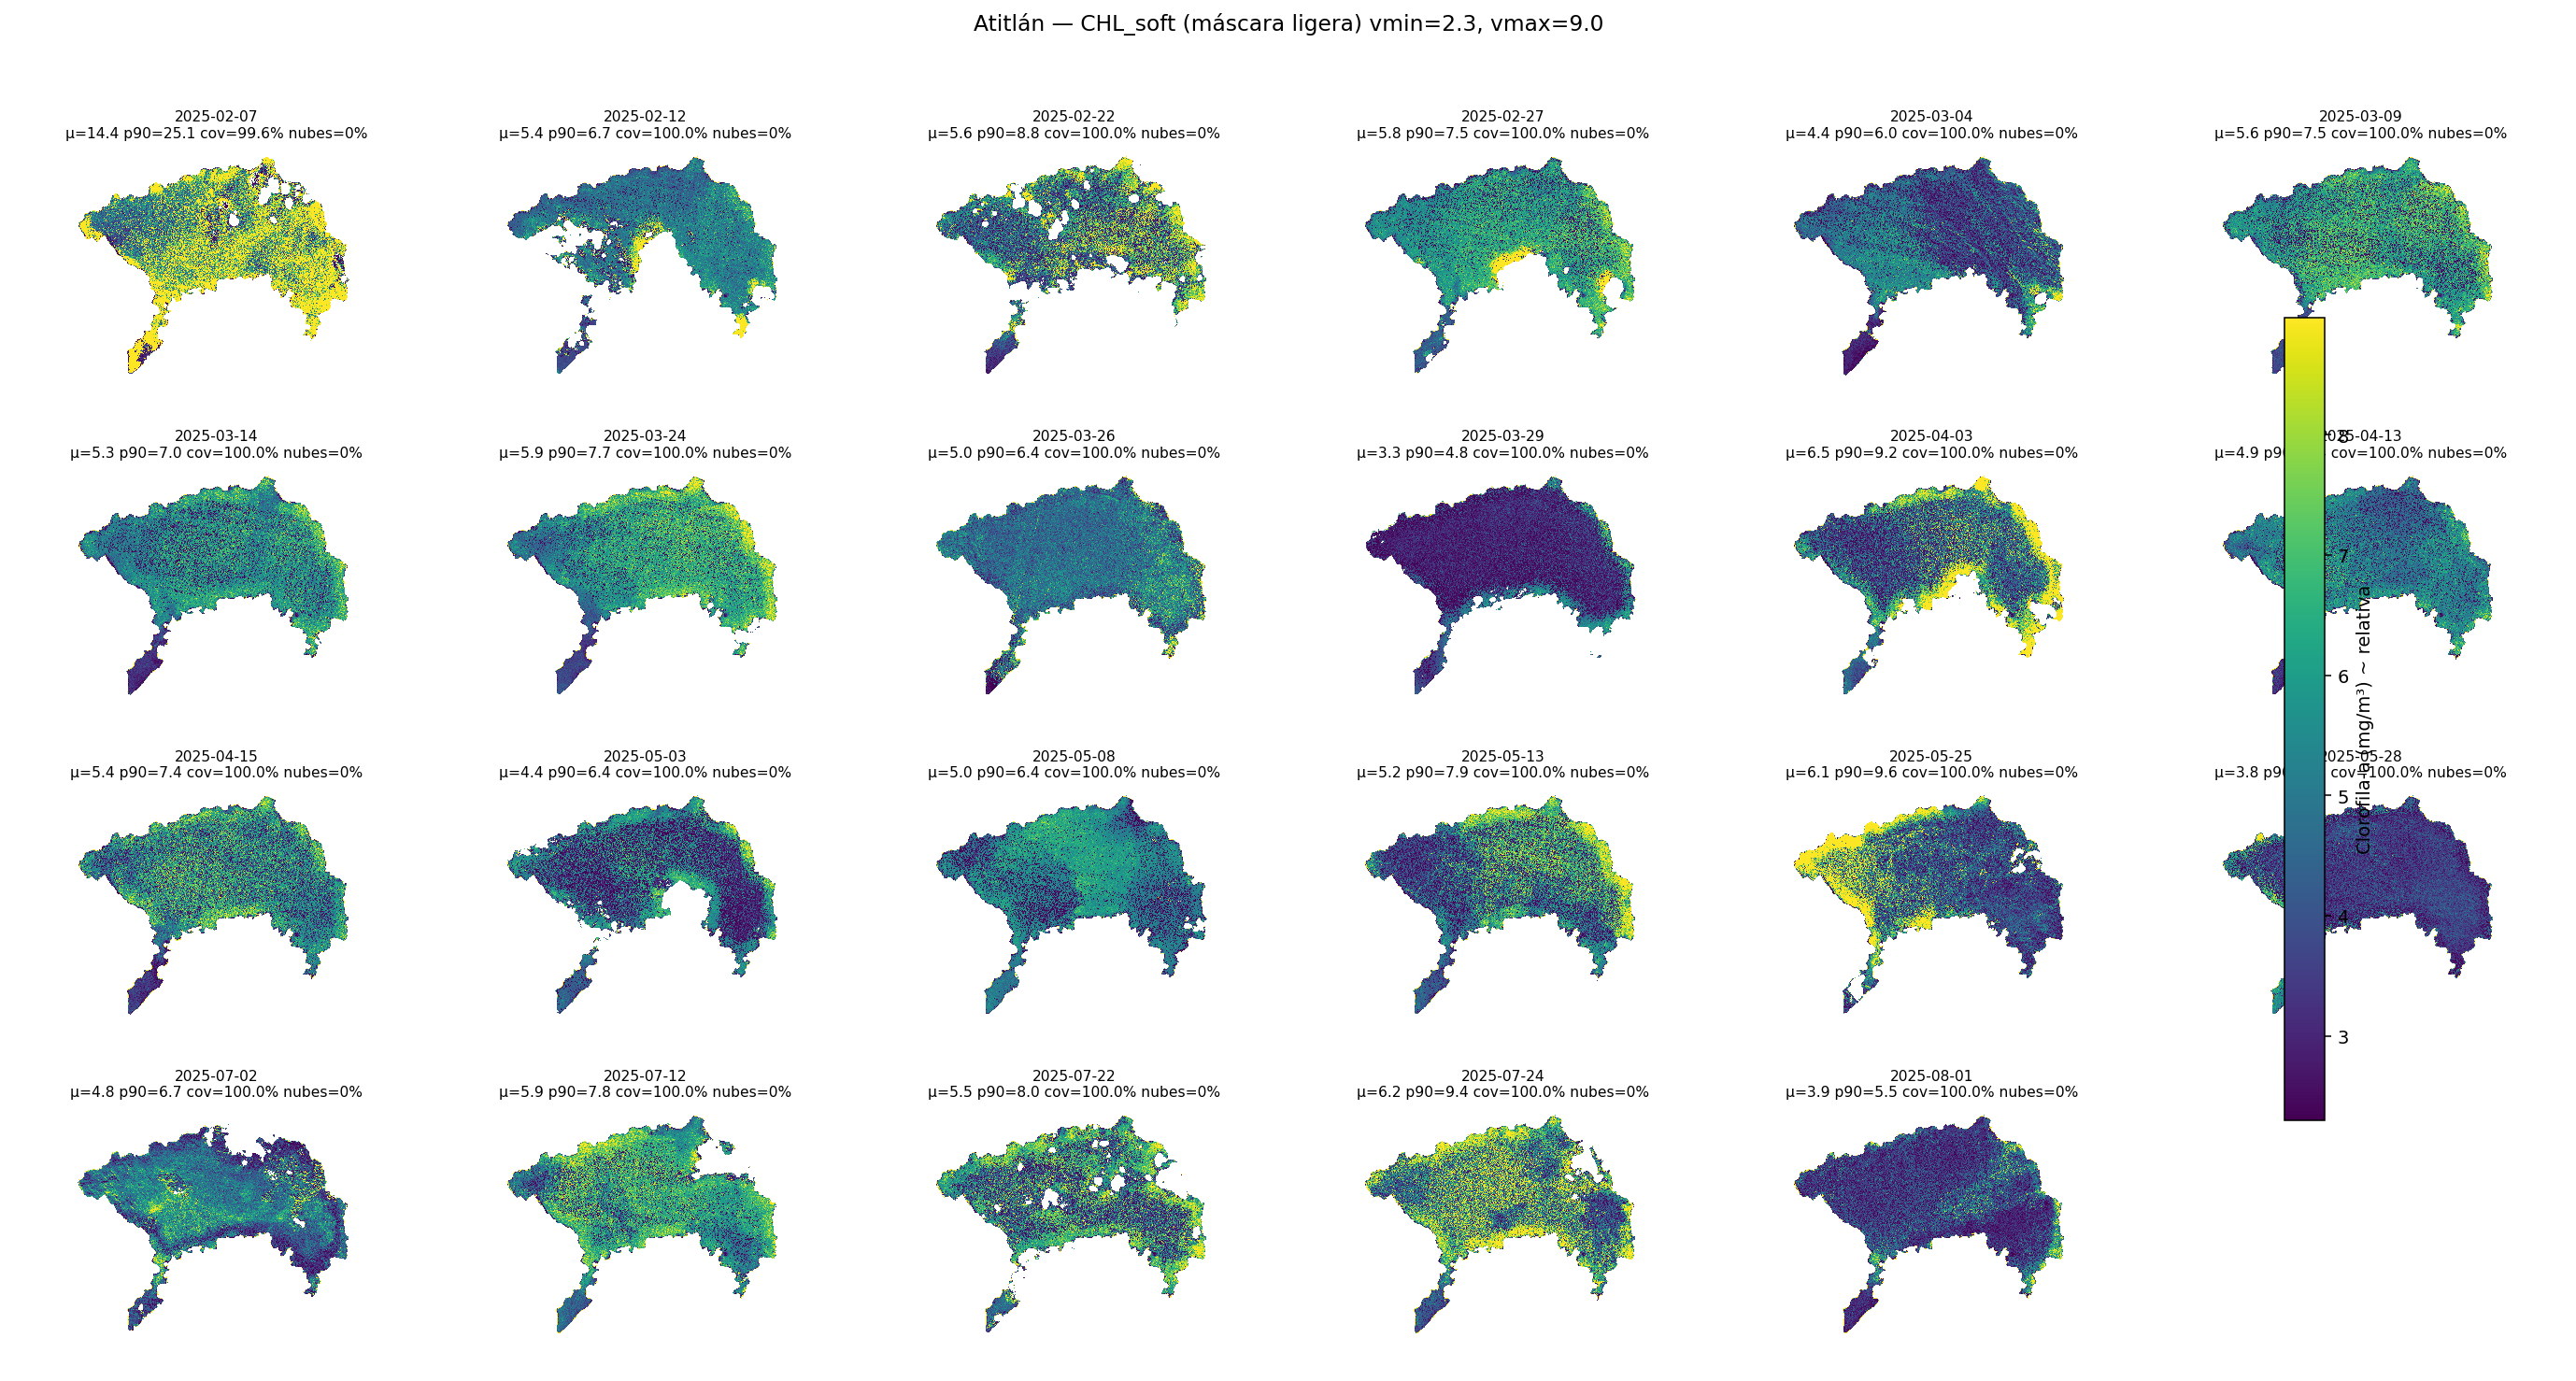

In [21]:
# ===============================================================
# CHL_soft (máscara ligera) desde L2A multibanda openEO_*Z.tif
# - Requiere: rasterio, numpy, pandas, matplotlib  (opcional: scipy)
#   pip install rasterio numpy pandas matplotlib scipy
# ===============================================================
import os, glob, re, json
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling, transform_geom
from rasterio import features
import matplotlib.pyplot as plt

# ------------------ CONFIG ------------------
LAKE_NAME = "Atitlán"
L2A_DIR   = "descargas_atitlan_fechas"          # <- donde están tus openEO_YYYY-MM-DDZ.tif
USE_POLYGON = os.path.exists("lago_atitlan.geojson")
LAKE_POLYGON_GEOJSON = "lago_atitlan.geojson"   # si existe, se usa
OUT_DIR   = "chl_soft_out"
NCOLS     = 6

# máscara ligera:
SCL_CLOUDS = {3,8,9,10,11}        # sombras, nubes med/altas, cirrus, nieve/hielo
ERODE_WATER_PIXELS = 0            # 0 = sin erosión (más laxo); sube a 1–2 si ves orillas sucias

# escala para galerías
V_CLAMP = (0, 200)                # mg/m³ aprox (puedes subir a 300 si tienes picos altos)
P_LOW, P_HIGH = 5, 95

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})", re.I)
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

# ------------------ UTILIDADES ------------------
def list_openEO(L2A_DIR):
    files = sorted(glob.glob(os.path.join(L2A_DIR, "openEO_*Z.tif")))
    items = []
    for p in files:
        m = DATE_RE.search(os.path.basename(p))
        if m:
            items.append((m.group(1), p))
    return items

def rasterize_polygon_on(transform, shape, dst_crs, geojson_path):
    with open(geojson_path, "r", encoding="utf-8") as f:
        gj = json.load(f)
    if gj.get("type") == "FeatureCollection":
        geoms = [g["geometry"] for g in gj["features"]]
    elif gj.get("type") == "Feature":
        geoms = [gj["geometry"]]
    else:
        geoms = [gj]
    geoms = [(transform_geom("EPSG:4326", dst_crs.to_string(), g), 1) for g in geoms]
    mask = features.rasterize(geoms, out_shape=shape, transform=transform,
                              fill=0, all_touched=True, dtype="uint8").astype(bool)
    return mask

def to_match_band(src_path, band_index, dst_tr, dst_crs, W, H, resampling=Resampling.bilinear):
    with rasterio.open(src_path) as src:
        out = np.full((H,W), np.nan, dtype=np.float32)
        reproject(
            source=rasterio.band(src, band_index),
            destination=out,
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=dst_tr,    dst_crs=dst_crs,
            resampling=resampling,
            src_nodata=src.nodata, dst_nodata=np.nan
        )
    return out

def soft_masks_from_SCL(scl, lake_mask):
    # rellena NaN de SCL con -1 para poder castear sin warnings
    scl = np.where(np.isfinite(scl), scl, -1).astype(np.int16)
    cloud_mask = np.isin(scl, list(SCL_CLOUDS))
    if USE_POLYGON:
        water_mask = lake_mask.copy()
    else:
        # SIN polígono: usa agua SCL==6 (más laxo imposible)
        water_mask = (scl == 6)
    if ERODE_WATER_PIXELS > 0:
        try:
            from scipy.ndimage import binary_erosion
            water_mask = binary_erosion(water_mask, iterations=ERODE_WATER_PIXELS,
                                        structure=np.ones((3,3), dtype=bool))
        except Exception:
            pass
    valid = water_mask & (~cloud_mask)
    return valid, water_mask, cloud_mask

def compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05):
    # Índices "suaves"
    tiny = 1e-6
    with np.errstate(divide='ignore', invalid='ignore'):
        ndci = (rrs_b05 - rrs_b04) / (rrs_b05 + rrs_b04 + tiny)
        oc3  = np.log10((rrs_b02 + tiny) / (rrs_b03 + tiny))
    # Combinación pragmática (ajusta coeficientes si quieres)
    chl_low  = 10 ** (0.4 + 3.0 * oc3)            # cloros bajas/medias
    chl_high = 40.0 * ndci + 2.0                  # cloros altas (lineal en NDCI)
    chl_soft = np.where(ndci > 0, chl_high, chl_low)
    chl_soft = np.clip(chl_soft, V_CLAMP[0], V_CLAMP[1])
    chl_soft[~np.isfinite(chl_soft)] = np.nan
    return ndci, oc3, chl_soft

# ------------------ PROCESAMIENTO ------------------
items = list_openEO(L2A_DIR)
if not items:
    raise SystemExit(f"No encontré multibandas openEO_*Z.tif en {L2A_DIR}")

rows, stacks = [], []
for date_iso, mb in items:
    with rasterio.open(mb) as src:
        H,W = src.height, src.width
        dst_tr, dst_crs = src.transform, src.crs
        # Sentinel-2 L2A (openEO): orden típico de bandas
        b02 = src.read(1).astype(np.float32)   # 490 nm
        b03 = src.read(2).astype(np.float32)   # 560 nm
        b04 = src.read(3).astype(np.float32)   # 665 nm
        b05 = src.read(4).astype(np.float32)   # 705 nm
        scl = src.read(10).astype(np.float32)  # SCL
        # escala a reflectancia 0..1
        rrs_b02 = b02 / 10000.0
        rrs_b03 = b03 / 10000.0
        rrs_b04 = b04 / 10000.0
        rrs_b05 = b05 / 10000.0

    # máscara lago
    if USE_POLYGON:
        lake_mask = rasterize_polygon_on(dst_tr, (H,W), dst_crs, LAKE_POLYGON_GEOJSON)
    else:
        lake_mask = np.ones((H,W), dtype=bool)

    # máscara ligera con SCL
    valid_mask, water_mask, cloud_mask = soft_masks_from_SCL(scl, lake_mask)

    # CHL_soft
    ndci, oc3, chl = compute_CHL_soft(rrs_b02, rrs_b03, rrs_b04, rrs_b05)
    chl_masked = np.where(valid_mask, chl, np.nan)

    # métricas rápidas
    lake_px = int(water_mask.sum())
    valid   = chl_masked[np.isfinite(chl_masked)]
    clouds_pct = float((cloud_mask & water_mask).sum())/max(lake_px,1)*100.0
    coverage_pct = 100.0 * valid.size / max(lake_px,1)
    row = dict(date=date_iso, lake_px=lake_px, valid_px=int(valid.size),
               clouds_pct_over_lake=clouds_pct,
               coverage_pct=coverage_pct,
               chl_mean=float(np.nanmean(valid)) if valid.size else np.nan,
               chl_median=float(np.nanmedian(valid)) if valid.size else np.nan,
               chl_p90=float(np.nanpercentile(valid,90)) if valid.size else np.nan,
               chl_max=float(np.nanmax(valid)) if valid.size else np.nan)
    rows.append(row)

    # guarda GeoTIFF de salida (CHL_soft)
    out_path = os.path.join(OUT_DIR, f"openEO_{date_iso}Z_chl_soft.tif")
    with rasterio.open(mb) as src:
        profile = src.profile
    profile.update(count=1, dtype="float32", nodata=np.nan)
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(chl_masked.astype(np.float32), 1)
    # almacena para galería
    stacks.append((date_iso, chl_masked))

# resumen CSV
df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
csv_path = os.path.join(OUT_DIR, f"resumen_{LAKE_NAME}_chl_soft.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Guardado: {csv_path}")

# ------------------ GALERÍAS ------------------
# escala global
vals = [a[np.isfinite(a)] for _,a in stacks if np.isfinite(a).any()]
if vals:
    allv = np.concatenate(vals)
    vmin = max(V_CLAMP[0], np.percentile(allv, P_LOW))
    vmax = min(V_CLAMP[1], np.percentile(allv, P_HIGH))
    if vmin >= vmax: vmax = vmin + 1.0
else:
    vmin, vmax = 0.0, 10.0
print(f"Escala global CHL_soft: vmin={vmin:.1f}, vmax={vmax:.1f}")

# panel
n = len(stacks)
ncols = min(NCOLS, n); nrows = int(np.ceil(n / ncols))
cmap = plt.cm.viridis.copy(); cmap.set_bad(alpha=0.0)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.3*ncols, 2.7*nrows), dpi=140, squeeze=False)
fig.suptitle(f"{LAKE_NAME} — CHL_soft (máscara ligera) vmin={vmin:.1f}, vmax={vmax:.1f}", y=0.995)
im_for_cbar=None
for i, (d, arr) in enumerate(stacks):
    r,c = divmod(i, ncols); ax = axes[r][c]
    im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, interpolation='none'); im_for_cbar = im
    ax.set_axis_off()
    m = df.loc[df["date"]==d].iloc[0]
    ax.set_title(f"{d}\nμ={m['chl_mean']:.1f} p90={m['chl_p90']:.1f} cov={m['coverage_pct']:.1f}% nubes={m['clouds_pct_over_lake']:.0f}%", fontsize=8)
for j in range(n, nrows*ncols):
    r,c = divmod(j, ncols); axes[r][c].set_visible(False)
if im_for_cbar is not None:
    cb = fig.colorbar(im_for_cbar, ax=axes, fraction=0.02, pad=0.02); cb.set_label("Clorofila-a (mg/m³) ~ relativa")
plt.tight_layout(rect=(0,0,1,0.97)); plt.show()


Escala global CHL_soft: vmin=2.3, vmax=9.0


C:\Users\Julio\AppData\Local\Temp\ipykernel_16156\3757438994.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0,0,1,0.97)); plt.show()


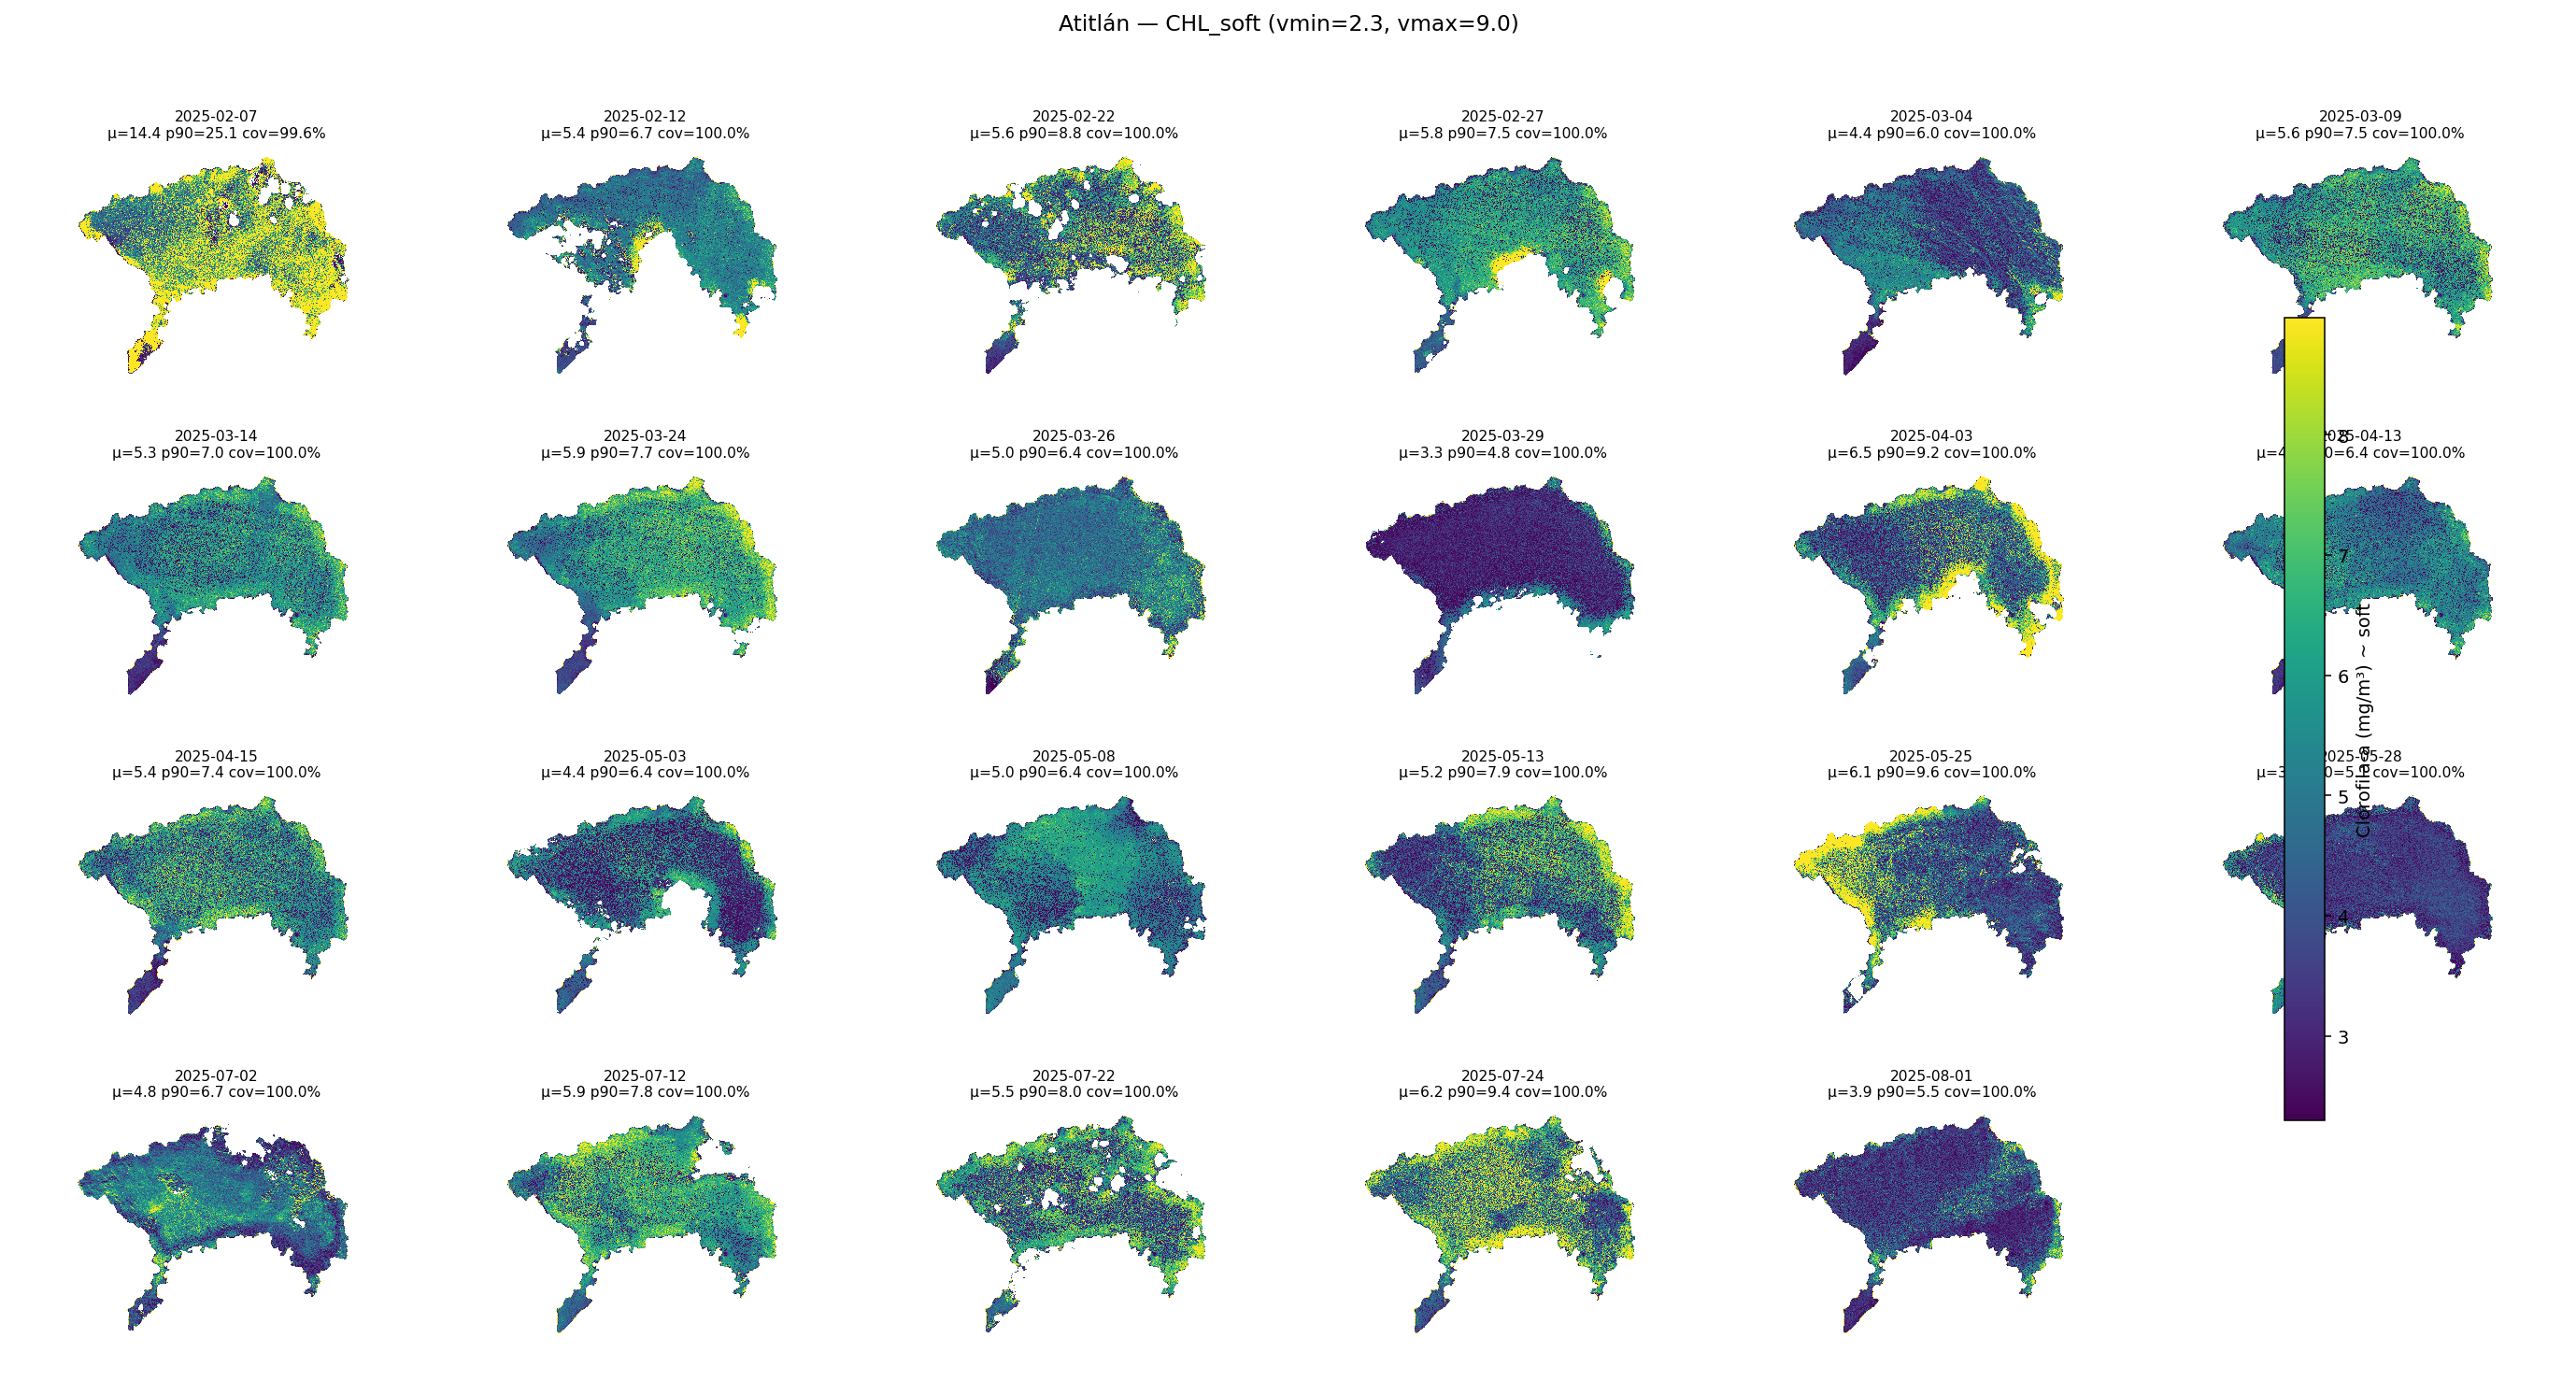

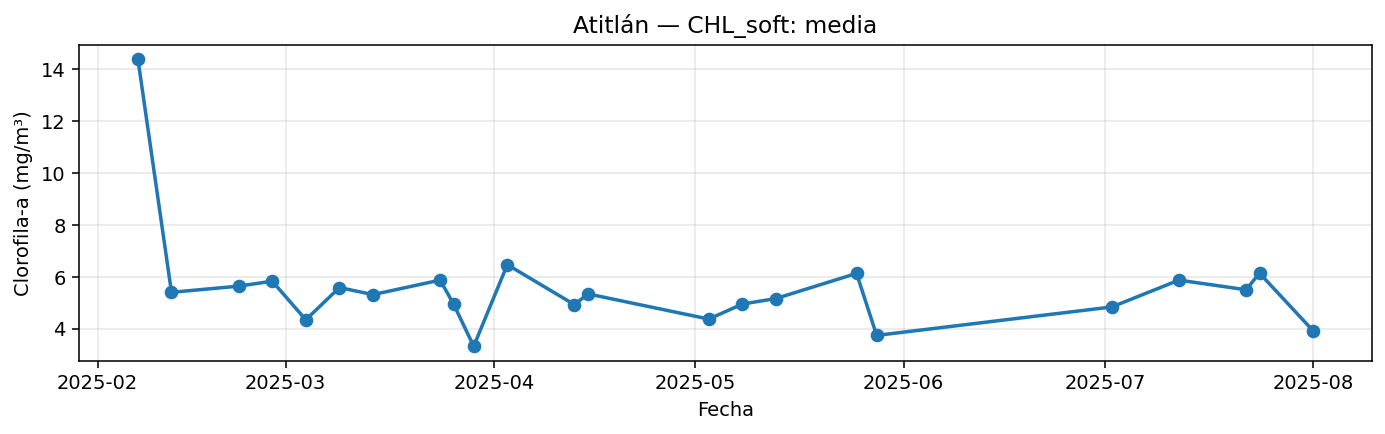

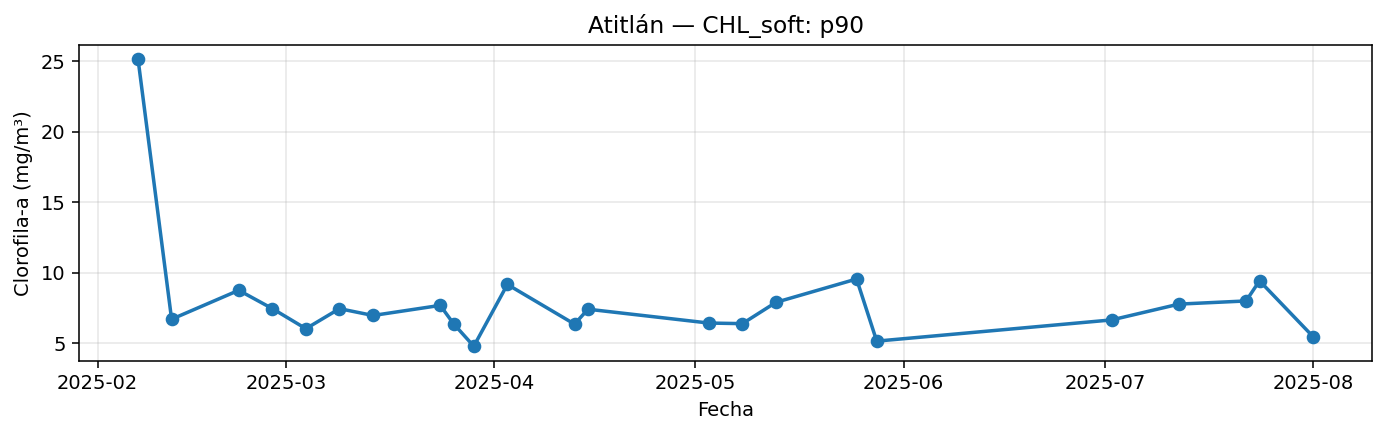

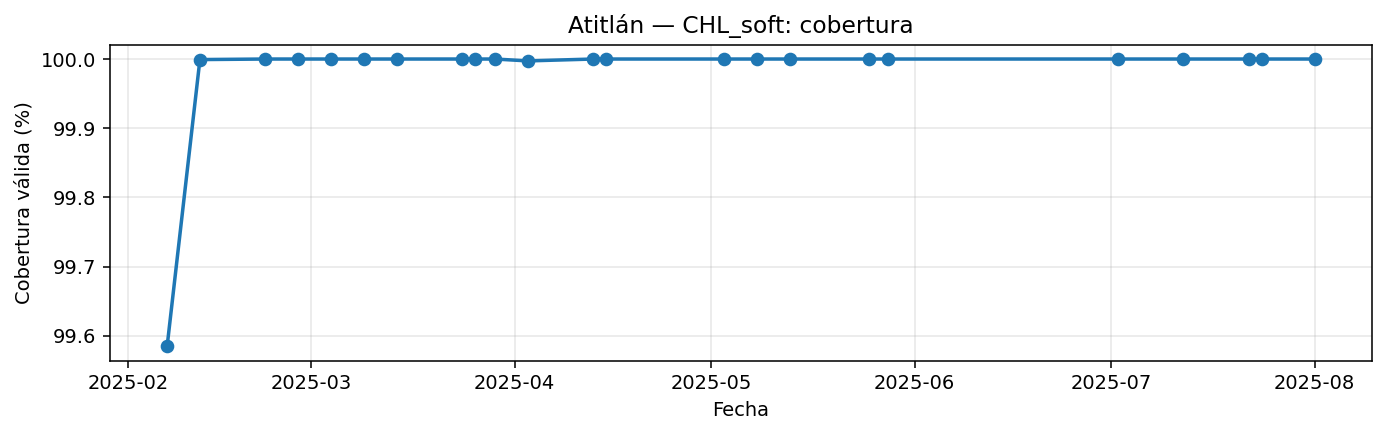

🟢 Top mejoras de cobertura (soft vs estricto):
      date  coverage_pct_strict  coverage_pct  coverage_gain
2025-04-15             0.000082         100.0      99.999918
2025-04-13             0.000082         100.0      99.999918
2025-03-26             0.000082         100.0      99.999918
2025-08-01             0.000082         100.0      99.999918
2025-03-14             0.000163         100.0      99.999837
2025-05-13             0.000163         100.0      99.999837
2025-03-24             0.000414         100.0      99.999586
2025-03-04             0.000576         100.0      99.999424
2025-07-12             0.000606         100.0      99.999394
2025-07-24             0.000760         100.0      99.999240


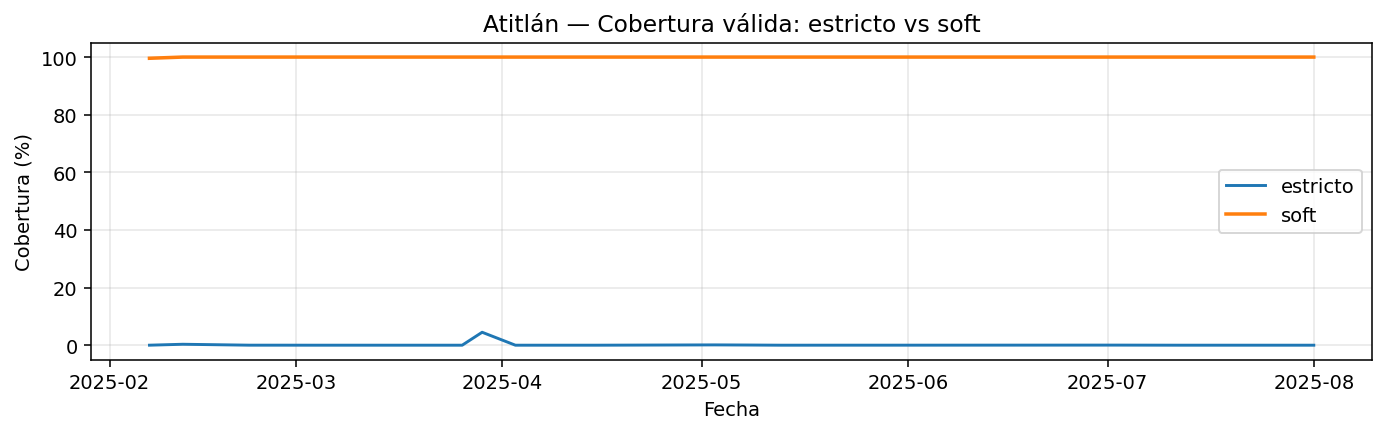

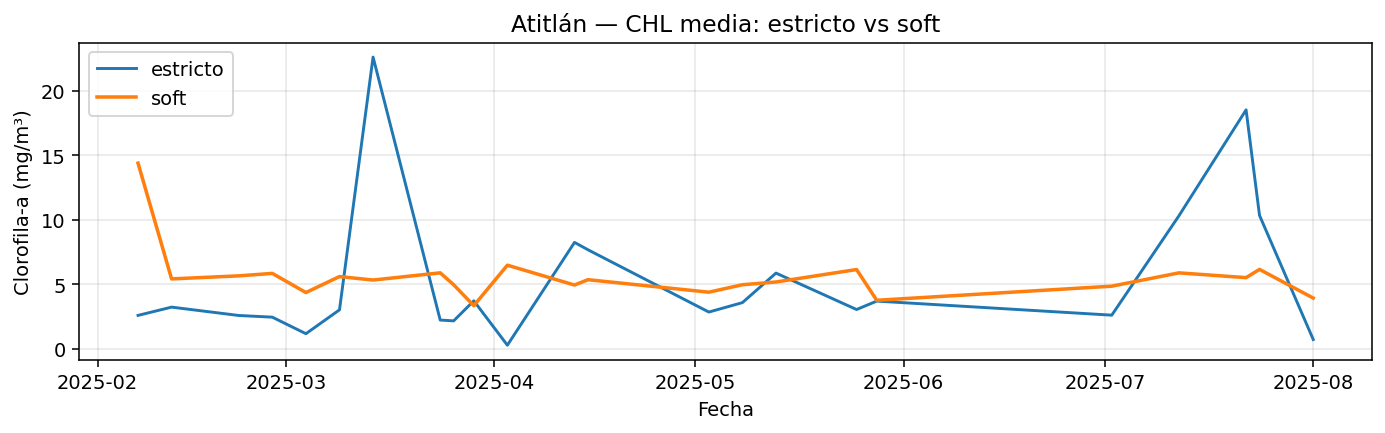

Resumen CHL_soft (principales métricas):
      date  coverage_pct  chl_mean   chl_p90    chl_max  valid_px  lake_px
2025-02-07     99.584940 14.396148 25.145712 200.000000   1194367  1199345
2025-02-12     99.999211  5.412135  6.701510 200.000000   1014007  1014015
2025-02-22    100.000000  5.649433  8.752954 200.000000   1054155  1054155
2025-02-27    100.000000  5.840075  7.454786 127.659355   1161855  1161855
2025-03-04    100.000000  4.353274  6.030896 200.000000   1227243  1227243
2025-03-09    100.000000  5.595356  7.450675  38.358994   1229854  1229854
2025-03-14    100.000000  5.323112  6.967415  85.456726   1236390  1236390
2025-03-24    100.000000  5.883004  7.682998  53.968273   1220991  1220991
2025-03-26    100.000000  4.958138  6.374885 200.000000   1236186  1236186
2025-03-29    100.000000  3.334841  4.786472  22.032463   1195829  1195829
2025-04-03     99.997291  6.476685  9.166519 200.000000   1181052  1181084
2025-04-13    100.000000  4.935853  6.353944  50.362598   1

In [22]:
# ===============================================================
# Explorer CHL_soft — Jupyter
# Visualiza los GeoTIFF *_chl_soft.tif y el CSV de resumen.
# Compara (opcional) contra el resumen "estricto" previo.
# Requiere: rasterio, numpy, pandas, matplotlib
# ===============================================================

import os, glob, re
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt

# ------------------ CONFIG ------------------
LAKE_NAME       = "Atitlán"
CHL_SOFT_DIR    = "chl_soft_out"  # carpeta con openEO_YYYY-MM-DDZ_chl_soft.tif y el CSV
SOFT_CSV        = os.path.join(CHL_SOFT_DIR, f"resumen_{LAKE_NAME}_chl_soft.csv")

# (opcional) CSV del pipeline estricto para comparar
STRICT_CSV      = "diagnosticos_v2/resumen_Atitlán_v2.csv"  # cámbialo si usas otro nombre

# parámetros visuales
NCOLS           = 6                    # columnas en la galería
P_LOW, P_HIGH   = 5, 95                # percentiles para la escala global
V_CLAMP         = (0, 200)             # rango plausible CHL_soft
DPI_FIG         = 140

# ------------------ UTILIDADES ------------------
DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})", re.I)

def list_soft_tifs(root):
    pats = [
        os.path.join(root, "*_chl_soft.tif"),
        os.path.join(root, "**", "*_chl_soft.tif"),
    ]
    files = []
    for p in pats:
        files.extend(glob.glob(p, recursive=True))
    items = []
    for f in sorted(set(files)):
        m = DATE_RE.search(os.path.basename(f))
        if m:
            items.append((m.group(1), f))
    items.sort(key=lambda t: t[0])
    return items

def load_arrays(paths):
    """Lee todas las fechas al tamaño de la primera (sin reproyección)."""
    if not paths:
        return []
    arrs = []
    with rasterio.open(paths[0]) as src0:
        H, W = src0.height, src0.width
    for p in paths:
        with rasterio.open(p) as src:
            a = src.read(1).astype(np.float32)
            if src.nodata is not None:
                a[a == src.nodata] = np.nan
            if (src.height, src.width) != (H, W):
                # si alguna difiere, re-muestrea simple (raro si todos vienen del mismo proceso)
                from rasterio.warp import reproject, Resampling
                out = np.full((H, W), np.nan, dtype=np.float32)
                reproject(
                    source=a, destination=out,
                    src_transform=src.transform, src_crs=src.crs,
                    dst_transform=src0.transform, dst_crs=src0.crs,
                    resampling=Resampling.bilinear,
                    src_nodata=np.nan, dst_nodata=np.nan
                )
                a = out
        arrs.append(a)
    return arrs

def global_scale(arrs, p_low=5, p_high=95, clamp=(0, 200)):
    vals = [a[np.isfinite(a)] for a in arrs if np.isfinite(a).any()]
    if not vals:
        return 0.0, 10.0
    v = np.concatenate(vals)
    vmin = max(clamp[0], np.percentile(v, p_low))
    vmax = min(clamp[1], np.percentile(v, p_high))
    if vmin >= vmax:
        vmax = vmin + 1.0
    return float(vmin), float(vmax)

# ------------------ CARGA DE DATOS ------------------
# CSV soft (si no existe, lo construimos mínimo a partir de los TIF)
if os.path.exists(SOFT_CSV):
    df_soft = pd.read_csv(SOFT_CSV, parse_dates=["date"])
else:
    print("⚠️ No encontré el CSV soft, construiré métricas mínimas desde los TIF…")
    items = list_soft_tifs(CHL_SOFT_DIR)
    if not items:
        raise SystemExit(f"No hay *_chl_soft.tif en {CHL_SOFT_DIR}")
    dates = [pd.to_datetime(d) for d,_ in items]
    arrs  = load_arrays([p for _,p in items])
    rows = []
    for d,a in zip(dates,arrs):
        valid = np.isfinite(a)
        lake_px = int(valid.size)
        valid_px = int(valid.sum())
        vals = a[valid]
        rows.append(dict(
            date=d, lake_px=lake_px, valid_px=valid_px,
            clouds_pct_over_lake=np.nan,  # no lo sabemos sin SCL aquí
            coverage_pct=100.0*valid_px/max(lake_px,1),
            chl_mean=float(np.nanmean(vals)) if vals.size else np.nan,
            chl_median=float(np.nanmedian(vals)) if vals.size else np.nan,
            chl_p90=float(np.nanpercentile(vals,90)) if vals.size else np.nan,
            chl_max=float(np.nanmax(vals)) if vals.size else np.nan
        ))
    df_soft = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

# TIFs soft
soft_items = list_soft_tifs(CHL_SOFT_DIR)
if not soft_items:
    raise SystemExit(f"No hay *_chl_soft.tif en {CHL_SOFT_DIR}")
soft_dates = [pd.to_datetime(d) for d,_ in soft_items]
soft_paths = [p for _,p in soft_items]
soft_arrs  = load_arrays(soft_paths)

# ------------------ GALERÍA CHL_soft ------------------
vmin, vmax = global_scale(soft_arrs, P_LOW, P_HIGH, V_CLAMP)
print(f"Escala global CHL_soft: vmin={vmin:.1f}, vmax={vmax:.1f}")

n = len(soft_arrs)
ncols = min(NCOLS, n)
nrows = int(np.ceil(n / ncols))
cmap = plt.cm.viridis.copy(); cmap.set_bad(alpha=0.0)

fig, axes = plt.subplots(nrows, ncols, figsize=(3.3*ncols, 2.7*nrows), dpi=DPI_FIG, squeeze=False)
fig.suptitle(f"{LAKE_NAME} — CHL_soft (vmin={vmin:.1f}, vmax={vmax:.1f})", y=0.995)
im_for_cbar = None
for i, (d, arr) in enumerate(zip(soft_dates, soft_arrs)):
    r,c = divmod(i, ncols); ax = axes[r][c]
    im = ax.imshow(arr, vmin=vmin, vmax=vmax, cmap=cmap, interpolation="none"); im_for_cbar = im
    ax.set_axis_off()
    row = df_soft.loc[df_soft["date"]==d].iloc[0] if (df_soft["date"]==d).any() else None
    if row is not None:
        ax.set_title(f"{d.date()}\nμ={row['chl_mean']:.1f} p90={row['chl_p90']:.1f} cov={row['coverage_pct']:.1f}%", fontsize=8)
    else:
        ax.set_title(str(d.date()), fontsize=8)
for j in range(n, nrows*ncols):
    r,c = divmod(j, ncols); axes[r][c].set_visible(False)
if im_for_cbar is not None:
    cb = fig.colorbar(im_for_cbar, ax=axes, fraction=0.02, pad=0.02); cb.set_label("Clorofila-a (mg/m³) ~ soft")
plt.tight_layout(rect=(0,0,1,0.97)); plt.show()

# ------------------ SERIES DE TIEMPO (SOFT) ------------------
df_soft = df_soft.sort_values("date")
for col, ylabel, title in [
    ("chl_mean",   "Clorofila-a (mg/m³)", f"{LAKE_NAME} — CHL_soft: media"),
    ("chl_p90",    "Clorofila-a (mg/m³)", f"{LAKE_NAME} — CHL_soft: p90"),
    ("coverage_pct","Cobertura válida (%)", f"{LAKE_NAME} — CHL_soft: cobertura"),
]:
    plt.figure(figsize=(10,3.2), dpi=DPI_FIG)
    plt.plot(df_soft["date"], df_soft[col], marker="o", linewidth=1.8)
    plt.grid(True, alpha=0.3)
    plt.title(title); plt.xlabel("Fecha"); plt.ylabel(ylabel)
    plt.tight_layout(); plt.show()

# ------------------ COMPARACIÓN (opcional) VS "ESTRICTO" ------------------
if os.path.exists(STRICT_CSV):
    df_strict = pd.read_csv(STRICT_CSV, parse_dates=["date"])
    # nos quedamos con columnas clave
    keep_cols = ["date","coverage_pct","chl_mean","chl_p90"]
    df_strict = df_strict[keep_cols].rename(columns={
        "coverage_pct":"coverage_pct_strict",
        "chl_mean":"chl_mean_strict",
        "chl_p90":"chl_p90_strict"
    })
    df_cmp = df_soft.merge(df_strict, on="date", how="left")

    # mejoras de cobertura
    if "coverage_pct_strict" in df_cmp.columns:
        df_cmp["coverage_gain"] = df_cmp["coverage_pct"] - df_cmp["coverage_pct_strict"]
        top = df_cmp.sort_values("coverage_gain", ascending=False)[["date","coverage_pct_strict","coverage_pct","coverage_gain"]]
        print("🟢 Top mejoras de cobertura (soft vs estricto):")
        print(top.head(10).to_string(index=False))

        # gráfico de coberturas
        plt.figure(figsize=(10,3.2), dpi=DPI_FIG)
        plt.plot(df_cmp["date"], df_cmp["coverage_pct_strict"], label="estricto", linewidth=1.5)
        plt.plot(df_cmp["date"], df_cmp["coverage_pct"], label="soft", linewidth=1.8)
        plt.grid(True, alpha=0.3); plt.legend()
        plt.title(f"{LAKE_NAME} — Cobertura válida: estricto vs soft")
        plt.xlabel("Fecha"); plt.ylabel("Cobertura (%)")
        plt.tight_layout(); plt.show()

    # comparación de medias (solo para contexto)
    if "chl_mean_strict" in df_cmp.columns:
        plt.figure(figsize=(10,3.2), dpi=DPI_FIG)
        plt.plot(df_cmp["date"], df_cmp["chl_mean_strict"], label="estricto", linewidth=1.5)
        plt.plot(df_cmp["date"], df_cmp["chl_mean"], label="soft", linewidth=1.8)
        plt.grid(True, alpha=0.3); plt.legend()
        plt.title(f"{LAKE_NAME} — CHL media: estricto vs soft")
        plt.xlabel("Fecha"); plt.ylabel("Clorofila-a (mg/m³)")
        plt.tight_layout(); plt.show()

else:
    print(f"ℹ️ No se encontró {STRICT_CSV}. Se omitió la comparación con el pipeline estricto.")

# ------------------ TABLA RESUMEN (SOFT) ------------------
display_cols = ["date","coverage_pct","chl_mean","chl_p90","chl_max","valid_px","lake_px"]
df_show = df_soft[display_cols].copy()
df_show["date"] = df_show["date"].dt.date
print("Resumen CHL_soft (principales métricas):")
print(df_show.to_string(index=False))


In [24]:
# === PASO 7 (solo guardar HTML): mapas por fechas pico y visor comparativo por lago ===
# Atitlán: usa CHL_soft (carpeta chl_soft_out, archivos *_chl_soft.tif)
# Amatitlán: usa CHL clásico (carpeta ciano_outputs/descargas_amatitlan, archivos *_chl.tif)

import os, glob, re
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import array_bounds
import folium
from branca.colormap import LinearColormap

# --- Config por lago ---
LAKES = {
    "Atitlán": {
        "root": "chl_soft_out",                           # << CHL_soft NUEVO
        "pattern": "*_chl_soft.tif",
        "zoom": 11,
        "clamp": (0, 120),                                # rango típico CHL_soft
        "peaks": [
            "2025-02-07","2025-02-12","2025-02-22","2025-02-27","2025-03-04",
            "2025-03-09","2025-03-14","2025-03-24","2025-03-26","2025-03-29",
            "2025-04-03","2025-04-13","2025-04-15","2025-05-03","2025-05-08",
            "2025-05-13","2025-05-25","2025-05-28","2025-07-02","2025-07-12",
            "2025-07-22","2025-07-24","2025-08-01"
        ],
    },
    "Amatitlán": {
        "root": os.path.join("ciano_outputs", "descargas_amatitlan"),   # << CHL clásico existente
        "pattern": "*_chl.tif",
        "zoom": 12,
        "clamp": (0, 100),
        "peaks": ["2025-01-13","2025-03-04","2025-03-24","2025-06-14","2025-08-13"],
    },
}

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})")
os.makedirs("html_maps", exist_ok=True)

# --- utilidades ---
def list_chl_tifs(lake_root, pattern):
    pats = [
        os.path.join(lake_root, pattern),
        os.path.join(lake_root, "**", pattern),
    ]
    files = []
    for p in pats:
        files.extend(glob.glob(p, recursive=True))
    items = []
    for p in sorted(set(files)):
        m = DATE_RE.search(os.path.basename(p))
        if m:
            items.append((pd.to_datetime(m.group(1)).date(), p))
    items.sort(key=lambda t: t[0])
    return [d.isoformat() for d,_ in items], [p for _,p in items]

def path_for_date(dates, paths, target):
    """Devuelve el tif exacto para 'target' (YYYY-MM-DD) o el más cercano temporalmente."""
    if target in dates:
        return paths[dates.index(target)], target, True
    if not dates:
        raise FileNotFoundError("No hay TIFs en la carpeta indicada.")
    dt = pd.to_datetime(dates)
    t  = pd.to_datetime(target)
    i  = int(np.argmin(np.abs((dt - t).days)))
    return paths[i], dates[i], False

def to_epsg4326(path, dst_transform=None, dst_width=None, dst_height=None):
    with rasterio.open(path) as src:
        src_crs, src_tr = src.crs, src.transform
        a = src.read(1).astype(np.float32)
        if src.nodata is not None:
            a[a == src.nodata] = np.nan
        if (src_crs is None) or (src_crs.to_string() == "EPSG:4326"):
            arr = a
            tr_out = src_tr
            if dst_transform is not None:
                arr2 = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
                reproject(a, arr2, src_transform=src_tr, src_crs=src_crs,
                          dst_transform=dst_transform, dst_crs="EPSG:4326",
                          resampling=Resampling.bilinear,
                          src_nodata=np.nan, dst_nodata=np.nan)
                arr = arr2; tr_out = dst_transform
        else:
            if dst_transform is None:
                dst_transform, dst_width, dst_height = calculate_default_transform(
                    src_crs, "EPSG:4326", src.width, src.height, *src.bounds
                )
            arr = np.full((dst_height, dst_width), np.nan, dtype=np.float32)
            reproject(a, arr, src_transform=src_tr, src_crs=src_crs,
                      dst_transform=dst_transform, dst_crs="EPSG:4326",
                      resampling=Resampling.bilinear,
                      src_nodata=np.nan, dst_nodata=np.nan)
            tr_out = dst_transform
        H, W = arr.shape
        left, bottom, right, top = array_bounds(H, W, tr_out)
        return arr, tr_out, (bottom, left, top, right)  # (S,W,N,E)

def common_vmin_vmax(arr_list, p_low=5, p_high=95, clamp=(0, 100)):
    vals = np.concatenate([a[np.isfinite(a)] for a in arr_list if np.isfinite(a).any()]) if arr_list else np.array([])
    if vals.size == 0:
        return 0.0, 10.0
    vmin = max(clamp[0], np.percentile(vals, p_low))
    vmax = min(clamp[1], np.percentile(vals, p_high))
    if vmin >= vmax: vmax = vmin + 1.0
    return float(vmin), float(vmax)

def rgba_for_folium(a, vmin, vmax, cmap="viridis"):
    import matplotlib.cm as cm, matplotlib.colors as colors
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    mapper = cm.ScalarMappable(norm=norm, cmap=cmap)
    rgba = mapper.to_rgba(a, bytes=True)
    rgba[~np.isfinite(a)] = [0,0,0,0]
    return rgba

# --- ejecución por lago ---
for lake, cfg in LAKES.items():
    print(f"\n=== {lake} ===")
    dates_all, paths_all = list_chl_tifs(cfg["root"], cfg["pattern"])
    if not paths_all:
        print(f"⚠️ No encontré TIFs en {cfg['root']} con patrón {cfg['pattern']}. Me salto {lake}.")
        continue

    selected = []
    base_arr, base_tr, base_bounds = None, None, None

    for t in cfg["peaks"]:
        tif_path, used_date, exact = path_for_date(dates_all, paths_all, t)
        if base_arr is None:
            base_arr, base_tr, base_bounds = to_epsg4326(tif_path)
            H, W = base_arr.shape
            arr = base_arr
        else:
            arr, _, _ = to_epsg4326(tif_path, dst_transform=base_tr, dst_width=W, dst_height=H)
        selected.append((used_date, arr))
        if not exact:
            print(f"  ⚠️ {t} no exacta, usando la más cercana: {used_date}")

    # Escala común por lago (con clamp específico)
    vmin, vmax = common_vmin_vmax([a for _, a in selected], clamp=cfg["clamp"])

    # Guardar un HTML por fecha
    south, west, north, east = base_bounds
    lat, lon = (south+north)/2, (west+east)/2
    for d, arr in selected:
        rgba = rgba_for_folium(arr, vmin=vmin, vmax=vmax)
        m = folium.Map(location=[lat, lon], zoom_start=cfg["zoom"], tiles="CartoDB positron")
        folium.raster_layers.ImageOverlay(
            image=rgba, bounds=[[south, west], [north, east]],
            opacity=0.75, name=f"{lake} – {d}", interactive=True
        ).add_to(m)
        LinearColormap(['#440154','#31688e','#35b779','#fde725'],
                       vmin=vmin, vmax=vmax,
                       caption="Clorofila-a (mg/m³)").add_to(m)
        folium.LayerControl().add_to(m)
        html_name = os.path.join("html_maps", f"mapa_{lake}_{d}.html".replace(" ", "_"))
        m.save(html_name)
        print(f"  ✔ Guardado: {html_name}")

    # Visor comparativo por lago (todas las fechas en capas)
    mcomp = folium.Map(location=[lat, lon], zoom_start=cfg["zoom"], tiles="CartoDB positron")
    for d, arr in selected:
        rgba = rgba_for_folium(arr, vmin=vmin, vmax=vmax)
        folium.raster_layers.ImageOverlay(
            image=rgba, bounds=[[south, west], [north, east]],
            opacity=0.75, name=d, interactive=True
        ).add_to(mcomp)
    LinearColormap(['#440154','#31688e','#35b779','#fde725'],
                   vmin=vmin, vmax=vmax, caption="Clorofila-a (mg/m³)").add_to(mcomp)
    folium.LayerControl().add_to(mcomp)
    comp_name = os.path.join("html_maps", f"mapa_comparativo_{lake}.html".replace(" ", "_"))
    mcomp.save(comp_name)
    print(f"  ✔ Visor comparativo guardado: {comp_name}")



=== Atitlán ===
  ✔ Guardado: html_maps\mapa_Atitlán_2025-02-07.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-02-12.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-02-22.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-02-27.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-03-04.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-03-09.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-03-14.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-03-24.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-03-26.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-03-29.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-04-03.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-04-13.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-04-15.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-05-03.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-05-08.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-05-13.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-05-25.html
  ✔ Guardado: html_maps\mapa_Atitlán_2025-05-28.html
  ✔ Guardado: html_maps\mapa_

## **Inciso 8**

In [ ]:
# ===============================================================
# Correlación NDVI / NDWI vs Cianobacteria (CHL)
# - Atitlán: usa CHL_soft en 'chl_soft_out'  (*_chl_soft.tif)
# - Amatitlán: usa CHL clásico en 'ciano_outputs/descargas_amatitlan' (*_chl.tif)
# Requiere: rasterio, numpy, pandas, matplotlib, scipy
# ===============================================================

import os, re, glob
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
LAKES = {
    "Atitlán": {
        "chl_root": "chl_soft_out",
        "chl_pattern": "*_chl_soft.tif",
        "l2a_root": "descargas_atitlan_fechas",
        "water_from_scl": True,
        "presence_thr": 10.0
    },
    "Amatitlán": {
        "chl_root": os.path.join("ciano_outputs", "descargas_amatitlan"),
        "chl_pattern": "*_chl.tif",
        "l2a_root": os.path.join("ciano_outputs", "descargas_amatitlan"),
        "water_from_scl": True,
        "presence_thr": 10.0
    }
}

OUT_DIR = "diagnosticos_corr"
os.makedirs(OUT_DIR, exist_ok=True)

DATE_RE = re.compile(r"(\d{4}-\d{2}-\d{2})", re.I)

# ---------------- UTILIDADES ----------------
def safe_nd(a, b):
    out = (a - b) / np.where((a + b) == 0, np.nan, (a + b))
    out[~np.isfinite(out)] = np.nan
    return out.astype(np.float32)

def list_by_date(root, pattern):
    pats = [os.path.join(root, pattern), os.path.join(root, "**", pattern)]
    files = []
    for p in pats:
        files.extend(glob.glob(p, recursive=True))
    items = []
    for f in sorted(set(files)):
        m = DATE_RE.search(os.path.basename(f))
        if m:
            items.append((m.group(1), f))
    items.sort(key=lambda t: t[0])
    return items

def find_l2a_for_date(l2a_root, date_iso):
    pat = f"**/openEO_{date_iso}Z.tif"
    cand = glob.glob(os.path.join(l2a_root, pat), recursive=True)
    return cand[0] if cand else None

def read_band(src, band_name):
    idx = {"B02":1, "B03":2, "B04":3, "B05":4, "B07":5, "B8A":6, "B08":7, "B11":8, "B12":9, "SCL":10}[band_name]
    a = src.read(idx).astype(np.float32)
    if src.nodata is not None:
        a[a == src.nodata] = np.nan
    return a

def reproject_like(src_arr, src_profile, dst_profile):
    out = np.full((dst_profile["height"], dst_profile["width"]), np.nan, dtype=np.float32)
    reproject(
        source=src_arr, destination=out,
        src_transform=src_profile["transform"], src_crs=src_profile["crs"],
        dst_transform=dst_profile["transform"], dst_crs=dst_profile["crs"],
        resampling=Resampling.bilinear,
        src_nodata=np.nan, dst_nodata=np.nan
    )
    return out

def sample_pairs(x, y, n=80000):
    m = np.isfinite(x) & np.isfinite(y)
    idx = np.where(m.ravel())[0]
    if idx.size == 0:
        return np.array([]), np.array([])
    if idx.size > n:
        idx = np.random.choice(idx, size=n, replace=False)
    xr = x.ravel()[idx]; yr = y.ravel()[idx]
    return xr, yr

def corr_pearson(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return np.nan
    return float(np.corrcoef(x[m], y[m])[0,1])

def corr_spearman(x, y):
    from scipy.stats import spearmanr
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return np.nan
    r, _ = spearmanr(x[m], y[m])
    return float(r)

# ---------------- PIPELINE POR LAGO ----------------
for lake, cfg in LAKES.items():
    print(f"\n=== {lake} ===")
    chl_items = list_by_date(cfg["chl_root"], cfg["chl_pattern"])
    if not chl_items:
        print(f"⚠️ No encontré CHL en {cfg['chl_root']} con {cfg['chl_pattern']}.")
        continue

    rows = []
    # Acumuladores PAREADOS por índice (para no mezclar longitudes)
    scat = {
        "ndvi":   {"chl": [], "idx": []},
        "ndwi_g": {"chl": [], "idx": []},
        "ndwi_s": {"chl": [], "idx": []},
    }

    for date_iso, chl_path in chl_items:
        l2a_path = find_l2a_for_date(cfg["l2a_root"], date_iso)
        if not l2a_path:
            print(f"  ⚠️ {date_iso}: no hay L2A openEO_{date_iso}Z.tif. Salto fecha.")
            continue

        # 1) Abrir L2A y calcular índices
        with rasterio.open(l2a_path) as src:
            prof_l2a = src.profile
            B03 = read_band(src, "B03")
            B04 = read_band(src, "B04")
            B08 = read_band(src, "B08")
            B8A = read_band(src, "B8A")
            B11 = read_band(src, "B11")
            SCL = read_band(src, "SCL").astype(np.float32)

        NDVI    = safe_nd(B08, B04)
        NDWI_G  = safe_nd(B03, B08)   # McFeeters
        NDWI_S  = safe_nd(B8A, B11)   # Gao

        # 2) Leer CHL y alinear a la malla de L2A
        with rasterio.open(chl_path) as sc:
            chl = sc.read(1).astype(np.float32)
            if sc.nodata is not None:
                chl[chl == sc.nodata] = np.nan
            prof_chl = sc.profile

        if (prof_chl["transform"] != prof_l2a["transform"]) or (prof_chl["crs"] != prof_l2a["crs"]) \
           or (prof_chl["width"] != prof_l2a["width"]) or (prof_chl["height"] != prof_l2a["height"]):
            chl = reproject_like(chl, prof_chl, prof_l2a)

        # 3) Máscara de agua & CHL válido
        if cfg["water_from_scl"] and np.isfinite(SCL).any():
            water = (SCL == 6)
        else:
            water = NDWI_G > 0.0
        mask = water & np.isfinite(chl)

        chl_vals = chl[mask]
        if chl_vals.size < 50:
            print(f"  ⚠️ {date_iso}: muy pocos píxeles válidos ({chl_vals.size}).")
            continue

        ndvi_vals   = NDVI[mask]
        ndwig_vals  = NDWI_G[mask]
        ndwis_vals  = NDWI_S[mask]

        # Correlaciones pixel-a-pixel
        r_ndvi_pix  = corr_spearman(chl_vals, ndvi_vals)
        r_ndwig_pix = corr_spearman(chl_vals, ndwig_vals)
        r_ndwis_pix = corr_spearman(chl_vals, ndwis_vals)

        # Agregados por fecha
        metrics = dict(
            lake=lake, date=pd.to_datetime(date_iso),
            chl_mean=float(np.nanmean(chl_vals)),
            chl_p90=float(np.nanpercentile(chl_vals, 90)),
            ndvi_mean=float(np.nanmean(ndvi_vals)),
            ndwi_g_mean=float(np.nanmean(ndwig_vals)),
            ndwi_s_mean=float(np.nanmean(ndwis_vals)),
            valid_px=int(mask.sum()),
        )

        thr = cfg["presence_thr"]
        present = (chl_vals >= thr)
        metrics.update({
            "presence_thr": thr,
            "presence_pct": 100.0 * present.mean(),
            "r_pix_ndvi_spearman": r_ndvi_pix,
            "r_pix_ndwi_g_spearman": r_ndwig_pix,
            "r_pix_ndwi_s_spearman": r_ndwis_pix,
            "r_pres_ndvi": corr_pearson(present.astype(np.float32), ndvi_vals),
            "r_pres_ndwi_g": corr_pearson(present.astype(np.float32), ndwig_vals),
            "r_pres_ndwi_s": corr_pearson(present.astype(np.float32), ndwis_vals),
        })
        rows.append(metrics)

        # Muestreo pareado por índice (evita longitudes distintas)
        x, y = sample_pairs(chl, NDVI)
        if x.size:
            scat["ndvi"]["chl"].append(x)
            scat["ndvi"]["idx"].append(y)

        x, y = sample_pairs(chl, NDWI_G)
        if x.size:
            scat["ndwi_g"]["chl"].append(x)
            scat["ndwi_g"]["idx"].append(y)

        x, y = sample_pairs(chl, NDWI_S)
        if x.size:
            scat["ndwi_s"]["chl"].append(x)
            scat["ndwi_s"]["idx"].append(y)

    if not rows:
        print(f"⚠️ {lake}: no se generaron filas.")
        continue

    df = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)
    csv_path = os.path.join(OUT_DIR, f"corr_indices_{lake}.csv")
    df.to_csv(csv_path, index=False)
    print(f"✅ Guardado CSV: {csv_path}")

    # ---- Series temporales
    def plot_ts(col, ylabel, title):
        plt.figure(figsize=(10,3.2), dpi=130)
        plt.plot(df["date"], df[col], marker="o", linewidth=1.8)
        plt.grid(True, alpha=0.3)
        plt.title(f"{lake} — {title}")
        plt.xlabel("Fecha"); plt.ylabel(ylabel)
        plt.tight_layout(); plt.show()

    plot_ts("chl_mean",    "Clorofila-a (mg/m³)", "CHL media")
    plot_ts("ndvi_mean",   "NDVI",                "NDVI medio (agua)")
    plot_ts("ndwi_g_mean", "NDWI (green–NIR)",    "NDWI_green medio")
    plot_ts("ndwi_s_mean", "NDWI (NIR–SWIR)",     "NDWI_swir medio")
    plot_ts("presence_pct","% píxeles con CHL≥thr","Presencia (%)")

    # Correlación de series (por fecha, medias del lago)
    from scipy.stats import spearmanr, pearsonr
    def series_corr(x, y):
        m = np.isfinite(x) & np.isfinite(y)
        if m.sum() < 5: return np.nan, np.nan
        rP,_ = pearsonr(x[m], y[m]); rS,_ = spearmanr(x[m], y[m])
        return float(rP), float(rS)

    p_ndvi, s_ndvi = series_corr(df["chl_mean"].values, df["ndvi_mean"].values)
    p_g, s_g       = series_corr(df["chl_mean"].values, df["ndwi_g_mean"].values)
    p_s, s_s       = series_corr(df["chl_mean"].values, df["ndwi_s_mean"].values)

    print(f"📈 {lake} — Correlación (medias por fecha):")
    print(f"  CHL vs NDVI   -> Pearson={p_ndvi:.3f}  Spearman={s_ndvi:.3f}")
    print(f"  CHL vs NDWI_g -> Pearson={p_g:.3f}     Spearman={s_g:.3f}")
    print(f"  CHL vs NDWI_s -> Pearson={p_s:.3f}     Spearman={s_s:.3f}")

    # ---- Scatter global: usa pares pareados por índice
    def join_pair(key):
        if scat[key]["chl"]:
            return np.concatenate(scat[key]["chl"]), np.concatenate(scat[key]["idx"])
        return np.array([]), np.array([])

    def scatter_one(x, y, xlabel, fname):
        if x.size == 0 or y.size == 0:
            print(f"  (sin muestras para {fname})")
            return
        rP = corr_pearson(x, y);  rS = corr_spearman(x, y)
        plt.figure(figsize=(6,5), dpi=130)
        plt.scatter(x, y, s=1, alpha=0.15)
        plt.xlabel(xlabel); plt.ylabel("Índice")
        plt.title(f"{lake} — rP={rP:.3f}, rS={rS:.3f}")
        plt.grid(True, alpha=0.2)
        out = os.path.join(OUT_DIR, f"{fname}_{lake}.png")
        plt.tight_layout(); plt.savefig(out); plt.show()
        print(f"  ✔ Guardado: {out}")

    x, y = join_pair("ndvi");    scatter_one(x, y, "CHL (mg/m³)", "scatter_CHL_vs_NDVI")
    x, y = join_pair("ndwi_g");  scatter_one(x, y, "CHL (mg/m³)", "scatter_CHL_vs_NDWI_green")
    x, y = join_pair("ndwi_s");  scatter_one(x, y, "CHL (mg/m³)", "scatter_CHL_vs_NDWI_swir")

print("\nListo:", OUT_DIR)


SyntaxError: invalid syntax (3196288017.py, line 198)